# [LAB-06] 캡스톤 (1) - MPG 데이터셋 (ADsP 기출)

1. 각 문제의 질문을 읽고, **어떤 그래프가 답을 찾기에 적절한지 스스로 판단**하여 직접 시각화하세요.
2. 그래프를 보고 객관식 보기 중 정답을 고르세요.

## 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot, my_qtcheck
from pandas import pivot_table
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("mpg")
origin.head()

📚 1999년과 2008년에 미국 EPA에서 조사하여 발표한 자동차 주요 모델별 연비 데이터 (출처: ADsP 기출 / R 내장 데이터)

    field         description
--  ------------  -------------------------------------------------------------
 0  manufacturer  자동차 제조사 (문자열)
 1  model         자동차 모델명 (문자열)
 2  displ         자동차 배기량 (연속형)
 3  year          제조년도 (연속형)
 4  cyl           엔진 실린더 수 (범주형)
 5  trans         자동차 트랜스미션 종류 (범주형)
 6  drv           자동차 구동 방식 (범주형). f=전륜구동, r=후륜구동, 4=사륜구동
 7  cty           도심 연비 (마일/갤론)
 8  hwy           고속도로 연비 (마일/갤론)
 9  fl            연료 종류 (범주형)
10  class         자동차 분류 (범주형)



,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),f,16,26,p,compact


### 3. 데이터 전처리

- 구동방식 컬럼 값을 이해하기 쉬운 값으로 변환

In [3]:
df = origin.copy()
df["drv"] = df["drv"].map({"f": "전륜구동", "r": "후륜구동", "4": "4륜구동"})
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact


## 문제 1. 출시 차량 수가 가장 많은 제조사는?

① audi  ② dodge  ③ toyota  ④ volkswagen

> 💡 **힌트**: 막대그래프 (제조사별 빈도)

### 정답 및 해설

**정답: ② dodge**

`manufacturer`의 빈도를 세면 dodge 37대, toyota 34대, volkswagen 27대, ford 25대 순입니다. 막대그래프로 가장 높은 막대를 찾으면 dodge가 정답입니다.

### 1. 제조사별 카운트 결과를 역순으로 정렬하여 추출

In [4]:
order = df["manufacturer"].value_counts().sort_values(ascending=False)
order

manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
audi          18
hyundai       14
subaru        14
nissan        13
honda          9
jeep           8
pontiac        5
land rover     4
mercury        4
lincoln        3
Name: count, dtype: int64

### 2. countplot 시각화

- 정렬된 제조사 이름을 정렬 순서로 지정한다.

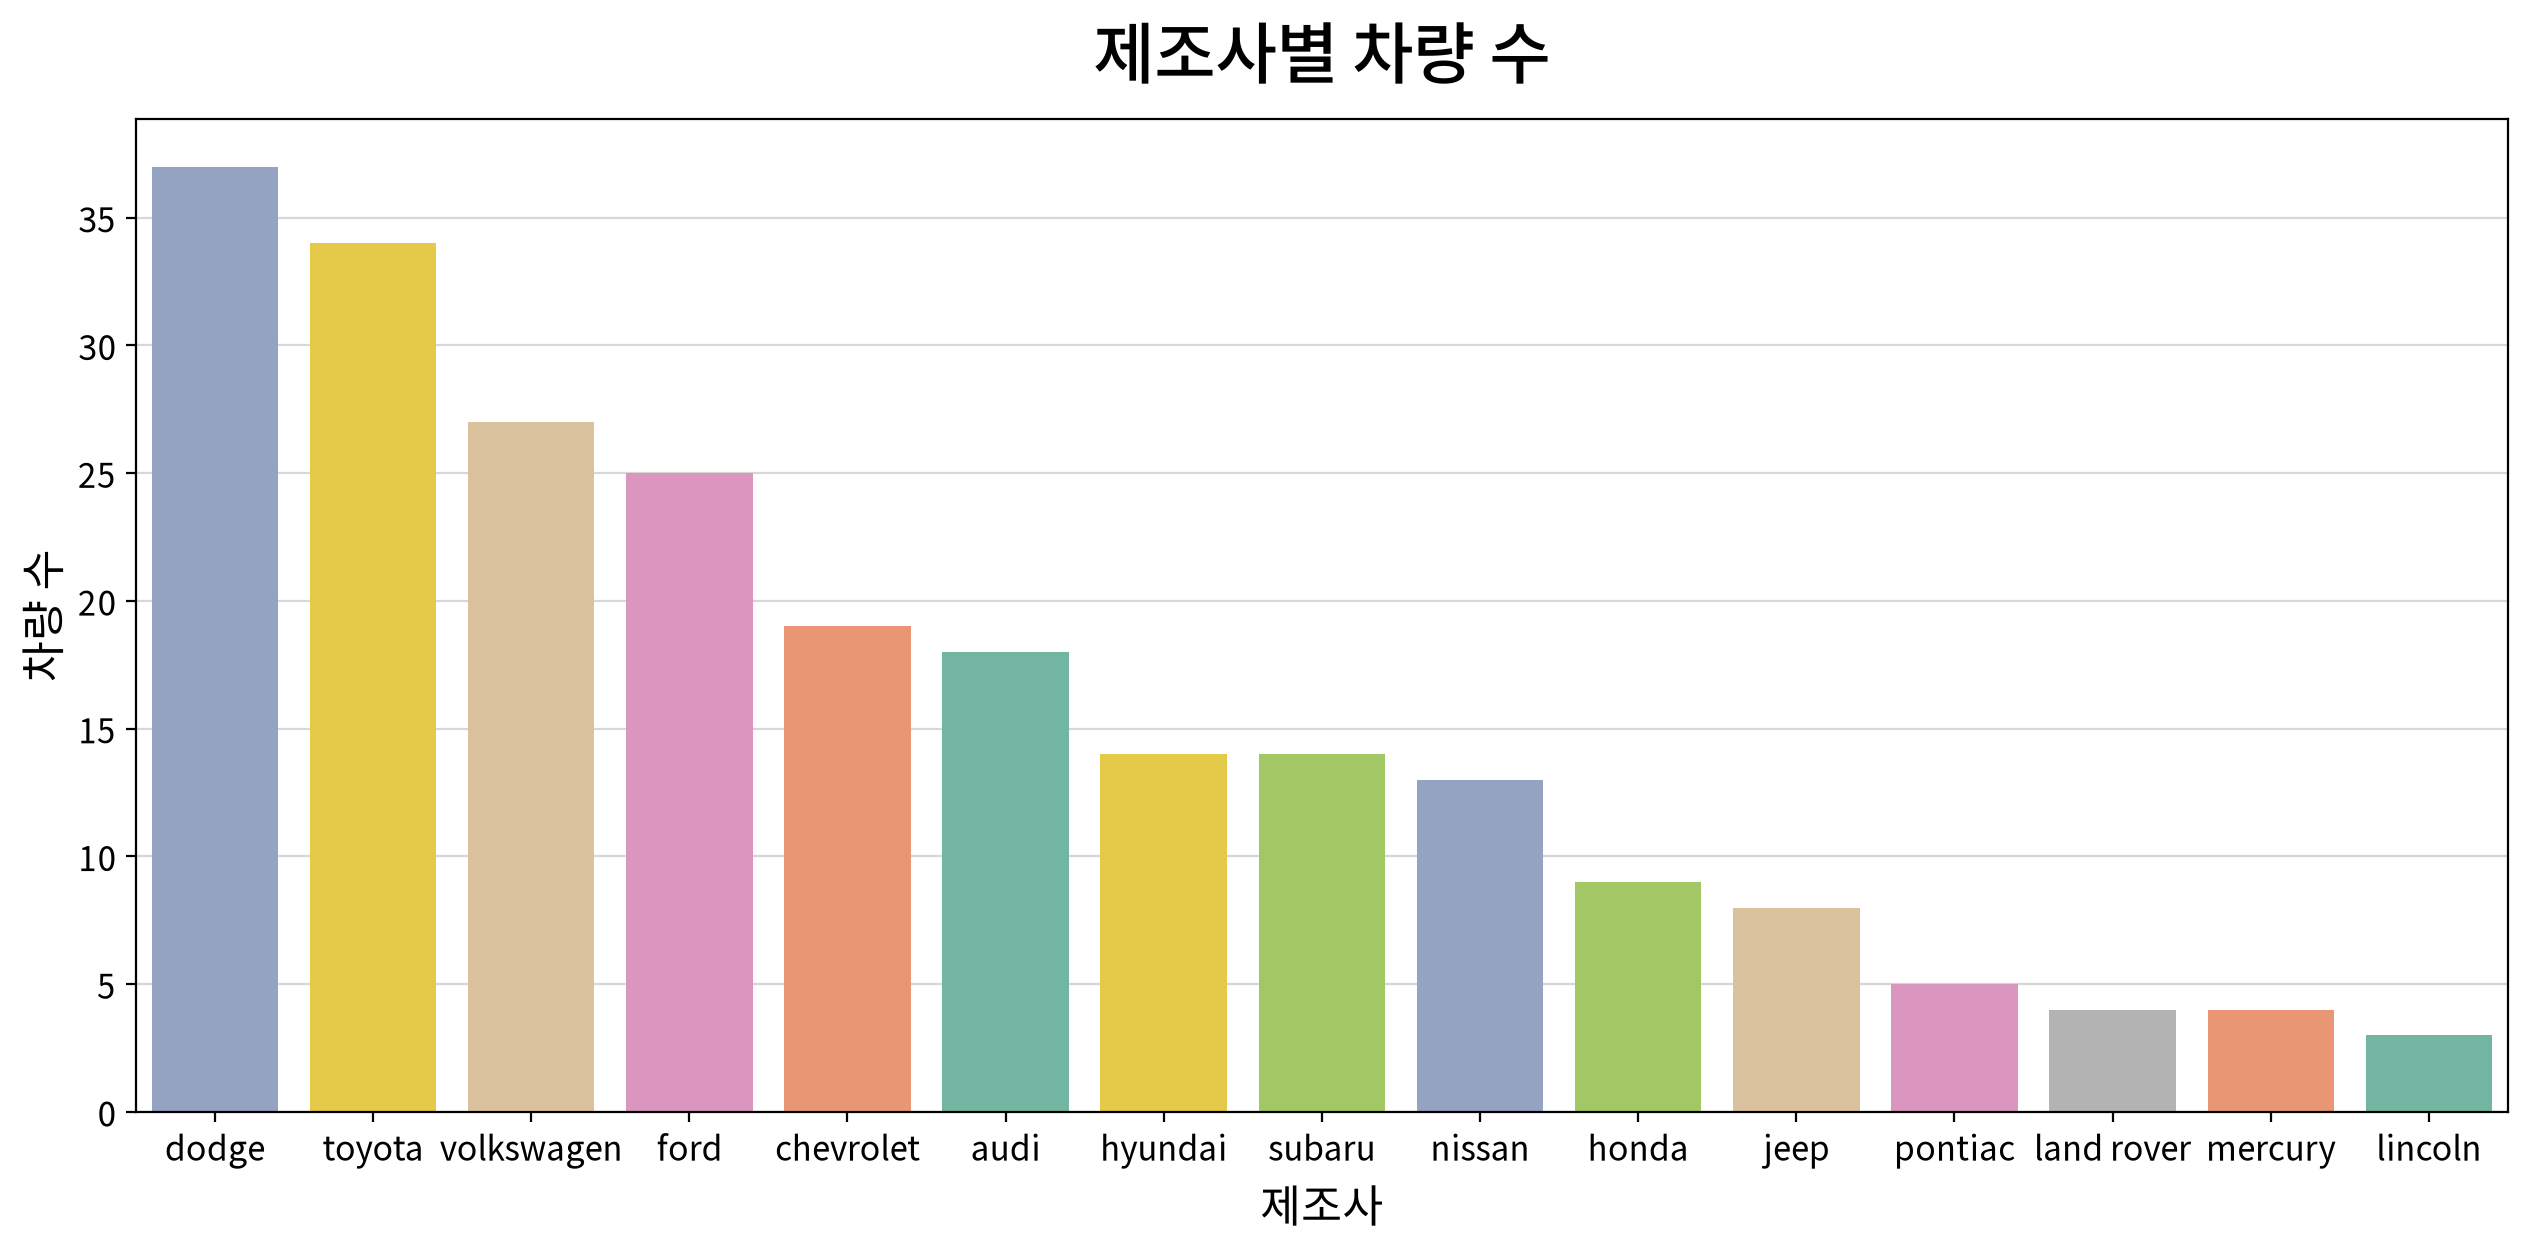

In [5]:
my_plot.countplot(data=df, x="manufacturer", order=order.index, 
                hue="manufacturer", palette="Set2", 
                title="제조사별 차량 수", xlabel="제조사", ylabel="차량 수")

## 문제 2. 차종(`class`) 중 가장 많은 비중을 차지하는 종류는?

① compact  ② midsize  ③ suv  ④ pickup

> 💡 **힌트**: 막대그래프 또는 원그래프 (차종별 빈도)

### 정답 및 해설

**정답: ③ suv**

차종별 차량 수는 suv 62대, compact 47대, midsize 41대, subcompact 35대, pickup 33대, minivan 11대, 2seater 5대입니다. suv가 가장 많습니다.


### 1. 차종별 집계

In [6]:
counts = df["class"].value_counts()
counts

class
suv           62
compact       47
midsize       41
subcompact    35
pickup        33
minivan       11
2seater        5
Name: count, dtype: int64

### 2. 차종별 원 그래프

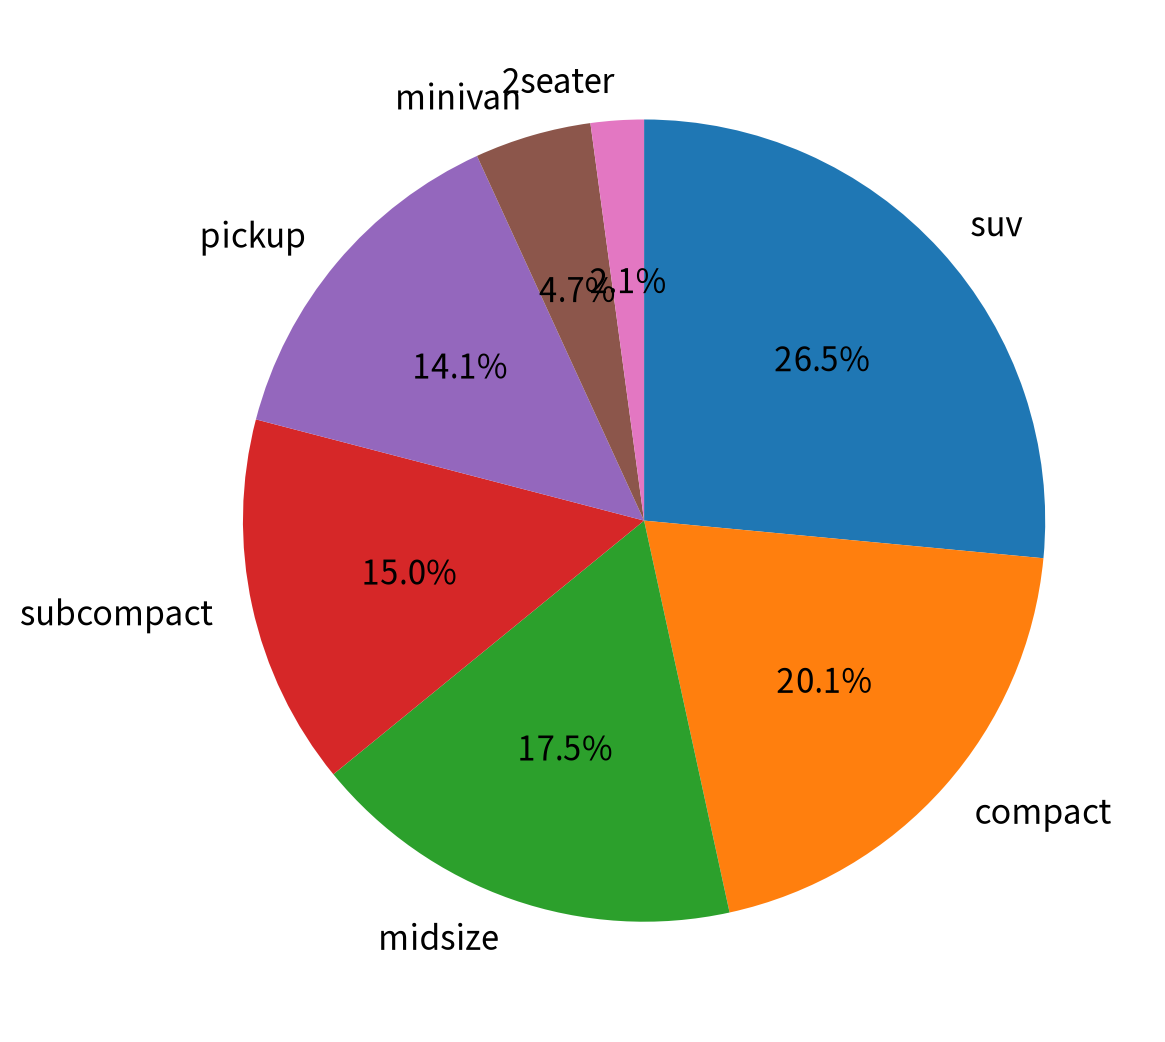

In [7]:
my_plot.pieplot(x=counts.values, labels=counts.index,
                width=600, height=600)

### 3. 차종별 비율 막대 그래프

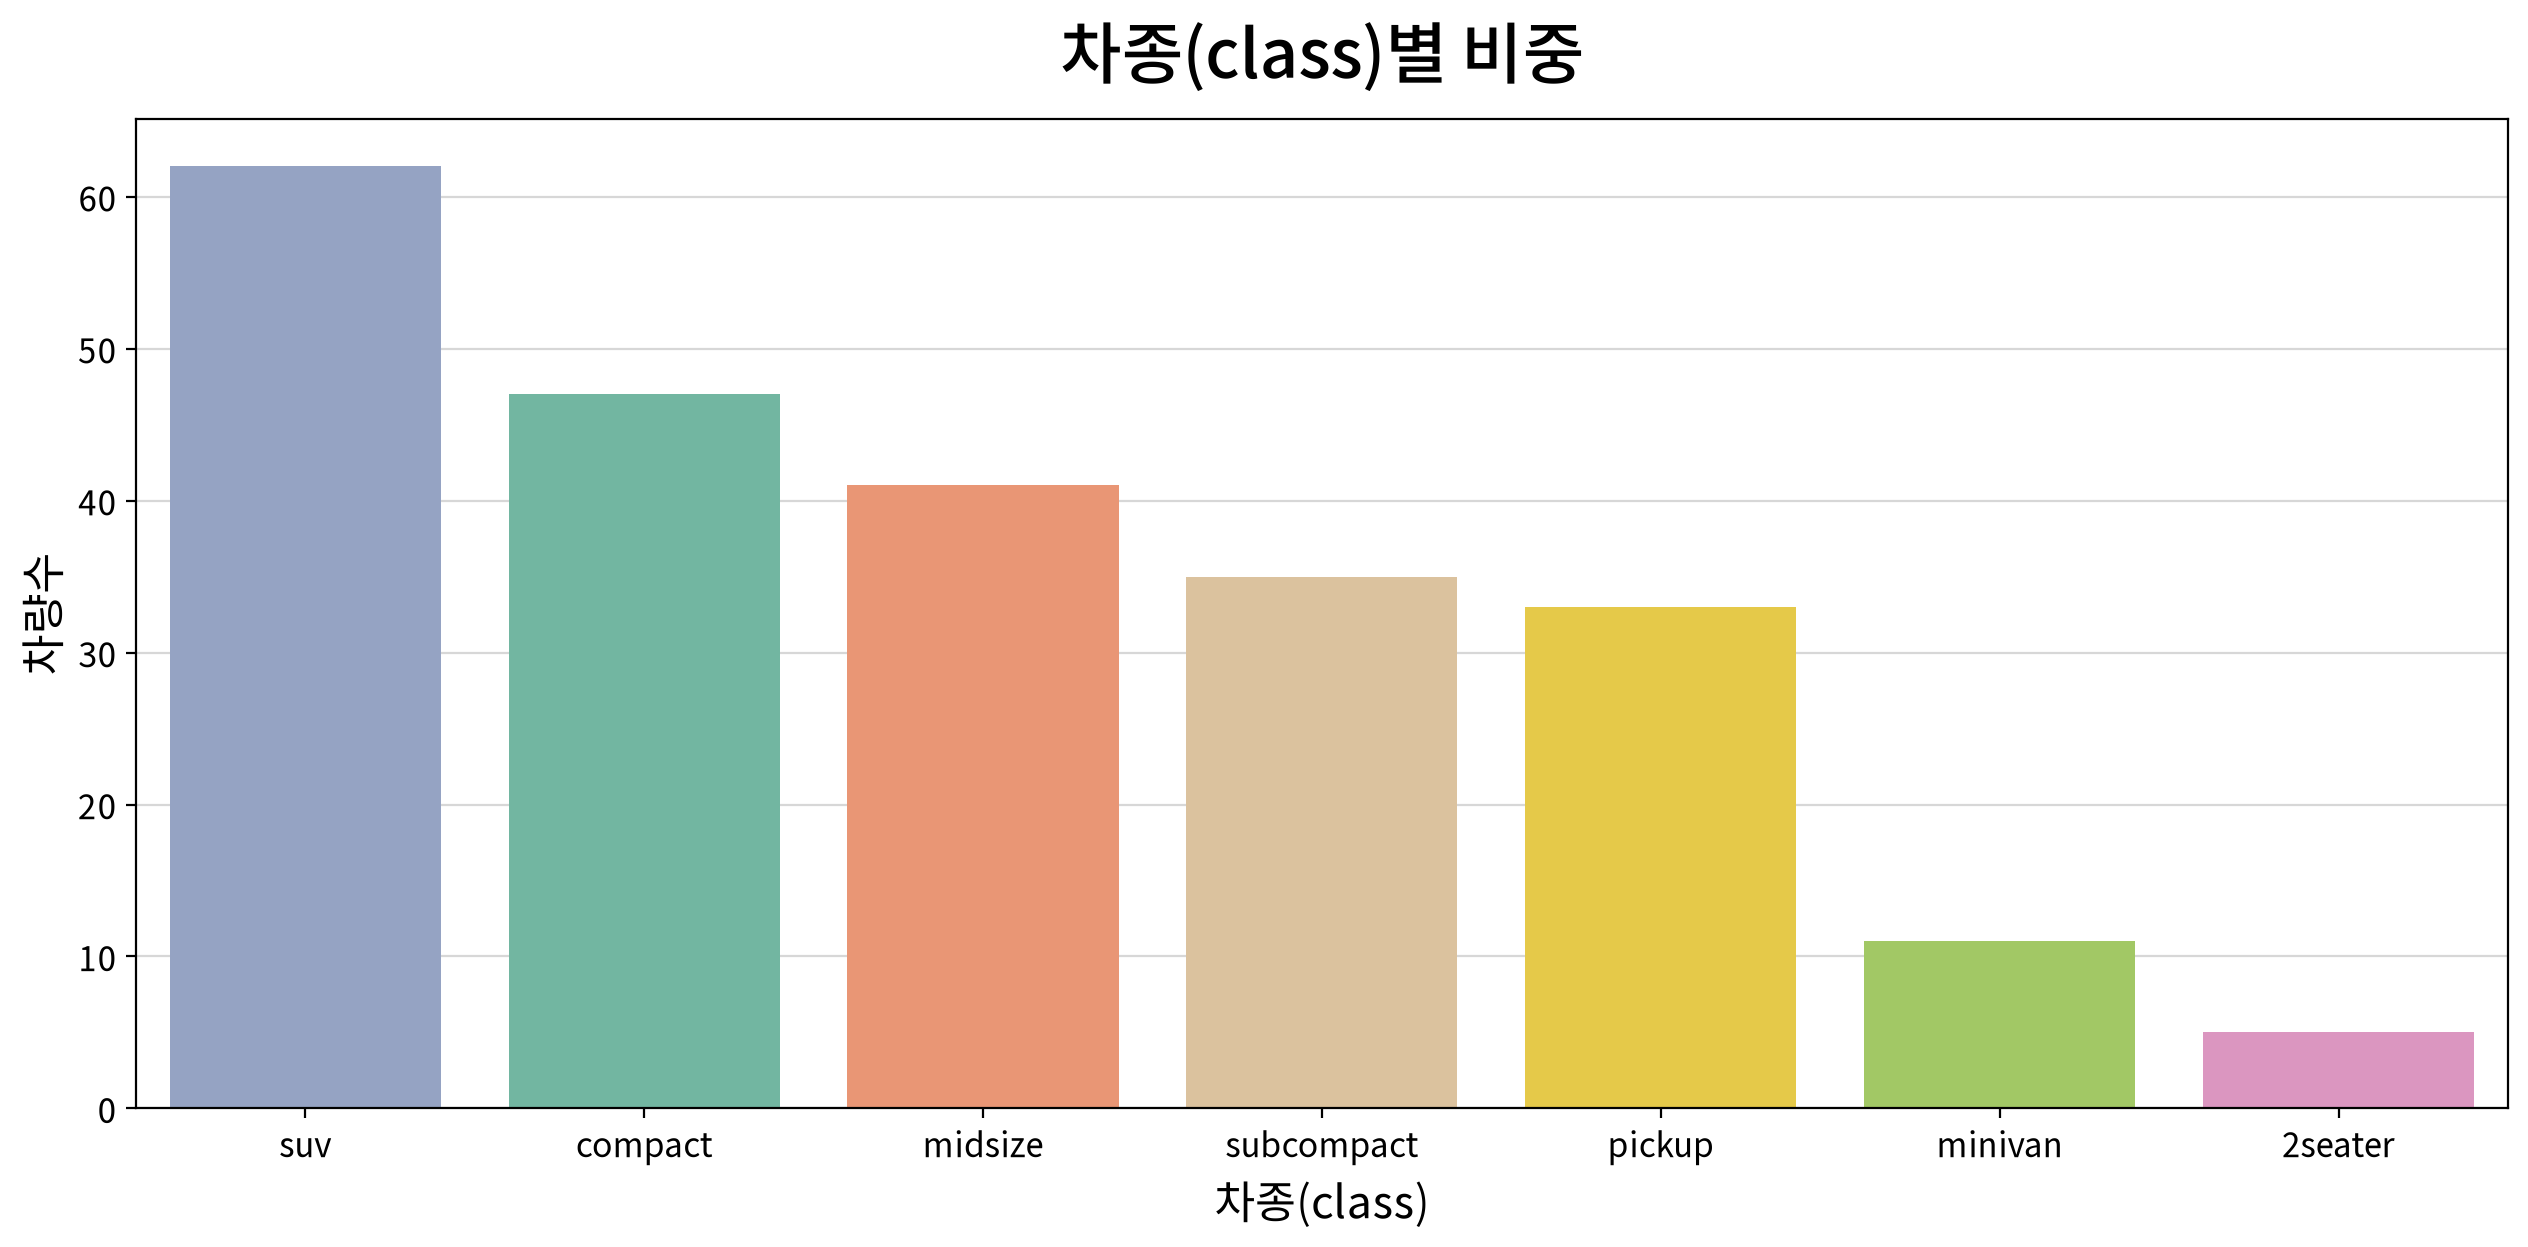

In [ ]:
my_plot.countplot(data=df, x='class', hue='class', 
                  order=counts.index, palette="Set2", 
                  title="차종(class)별 비중", xlabel="차종(class)", 
                  ylabel="차량수")

## 문제 3. 구동방식(`drv`) 중 차량 수가 가장 적은 방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 동일

> 💡 **힌트**: 막대그래프 (구동방식별 빈도)

### 정답 및 해설

**정답: ③ 후륜구동**

전륜구동 106대, 4륜구동 103대, 후륜구동 25대로 후륜구동이 가장 적습니다.


### 2. 구동방식별 Count Plot 시각화

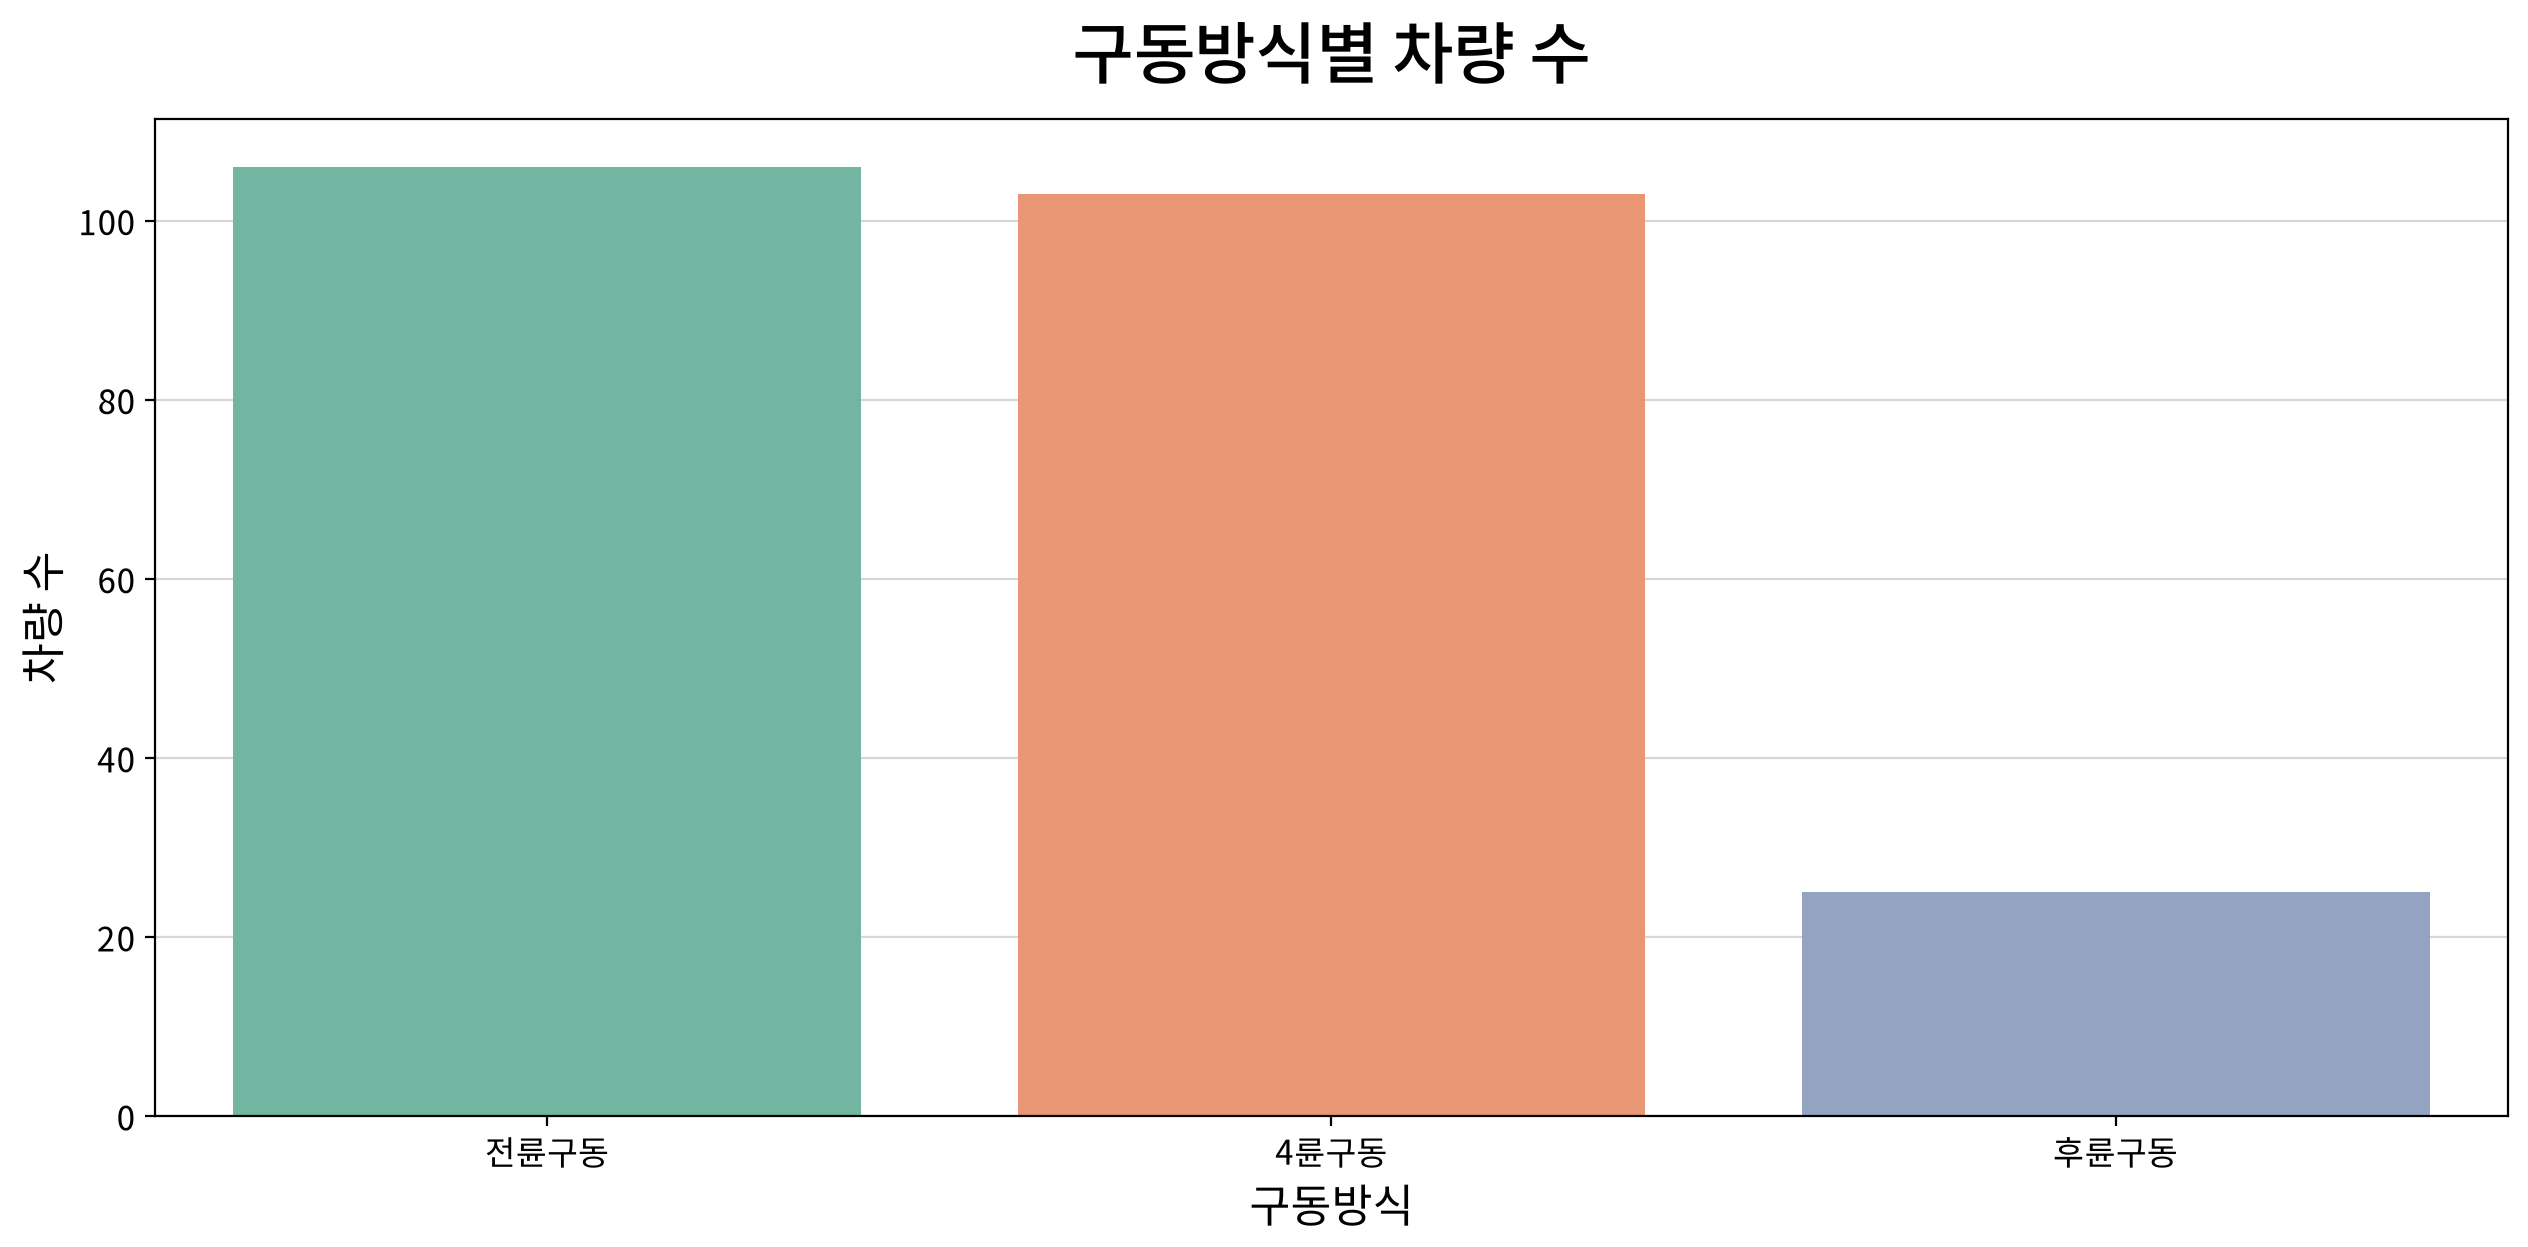

In [ ]:
my_plot.countplot(data=df, x="drv", order=df['drv'].value_counts().index, 
                  hue="drv", palette="Set2", title="구동방식별 차량 수", xlabel="구동방식", ylabel="차량 수")

## 문제 4. 도심 연비(`cty`) 평균이 가장 높은 구동방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 비슷

> 💡 **힌트**: 막대그래프 (구동방식별 cty 평균)

### 정답 및 해설

**정답: ① 전륜구동**

구동방식별 도심 연비 평균은 전륜구동 약 19.97, 4륜구동 약 14.33, 후륜구동 약 14.08입니다. 전륜구동이 도심 연비가 가장 좋습니다.


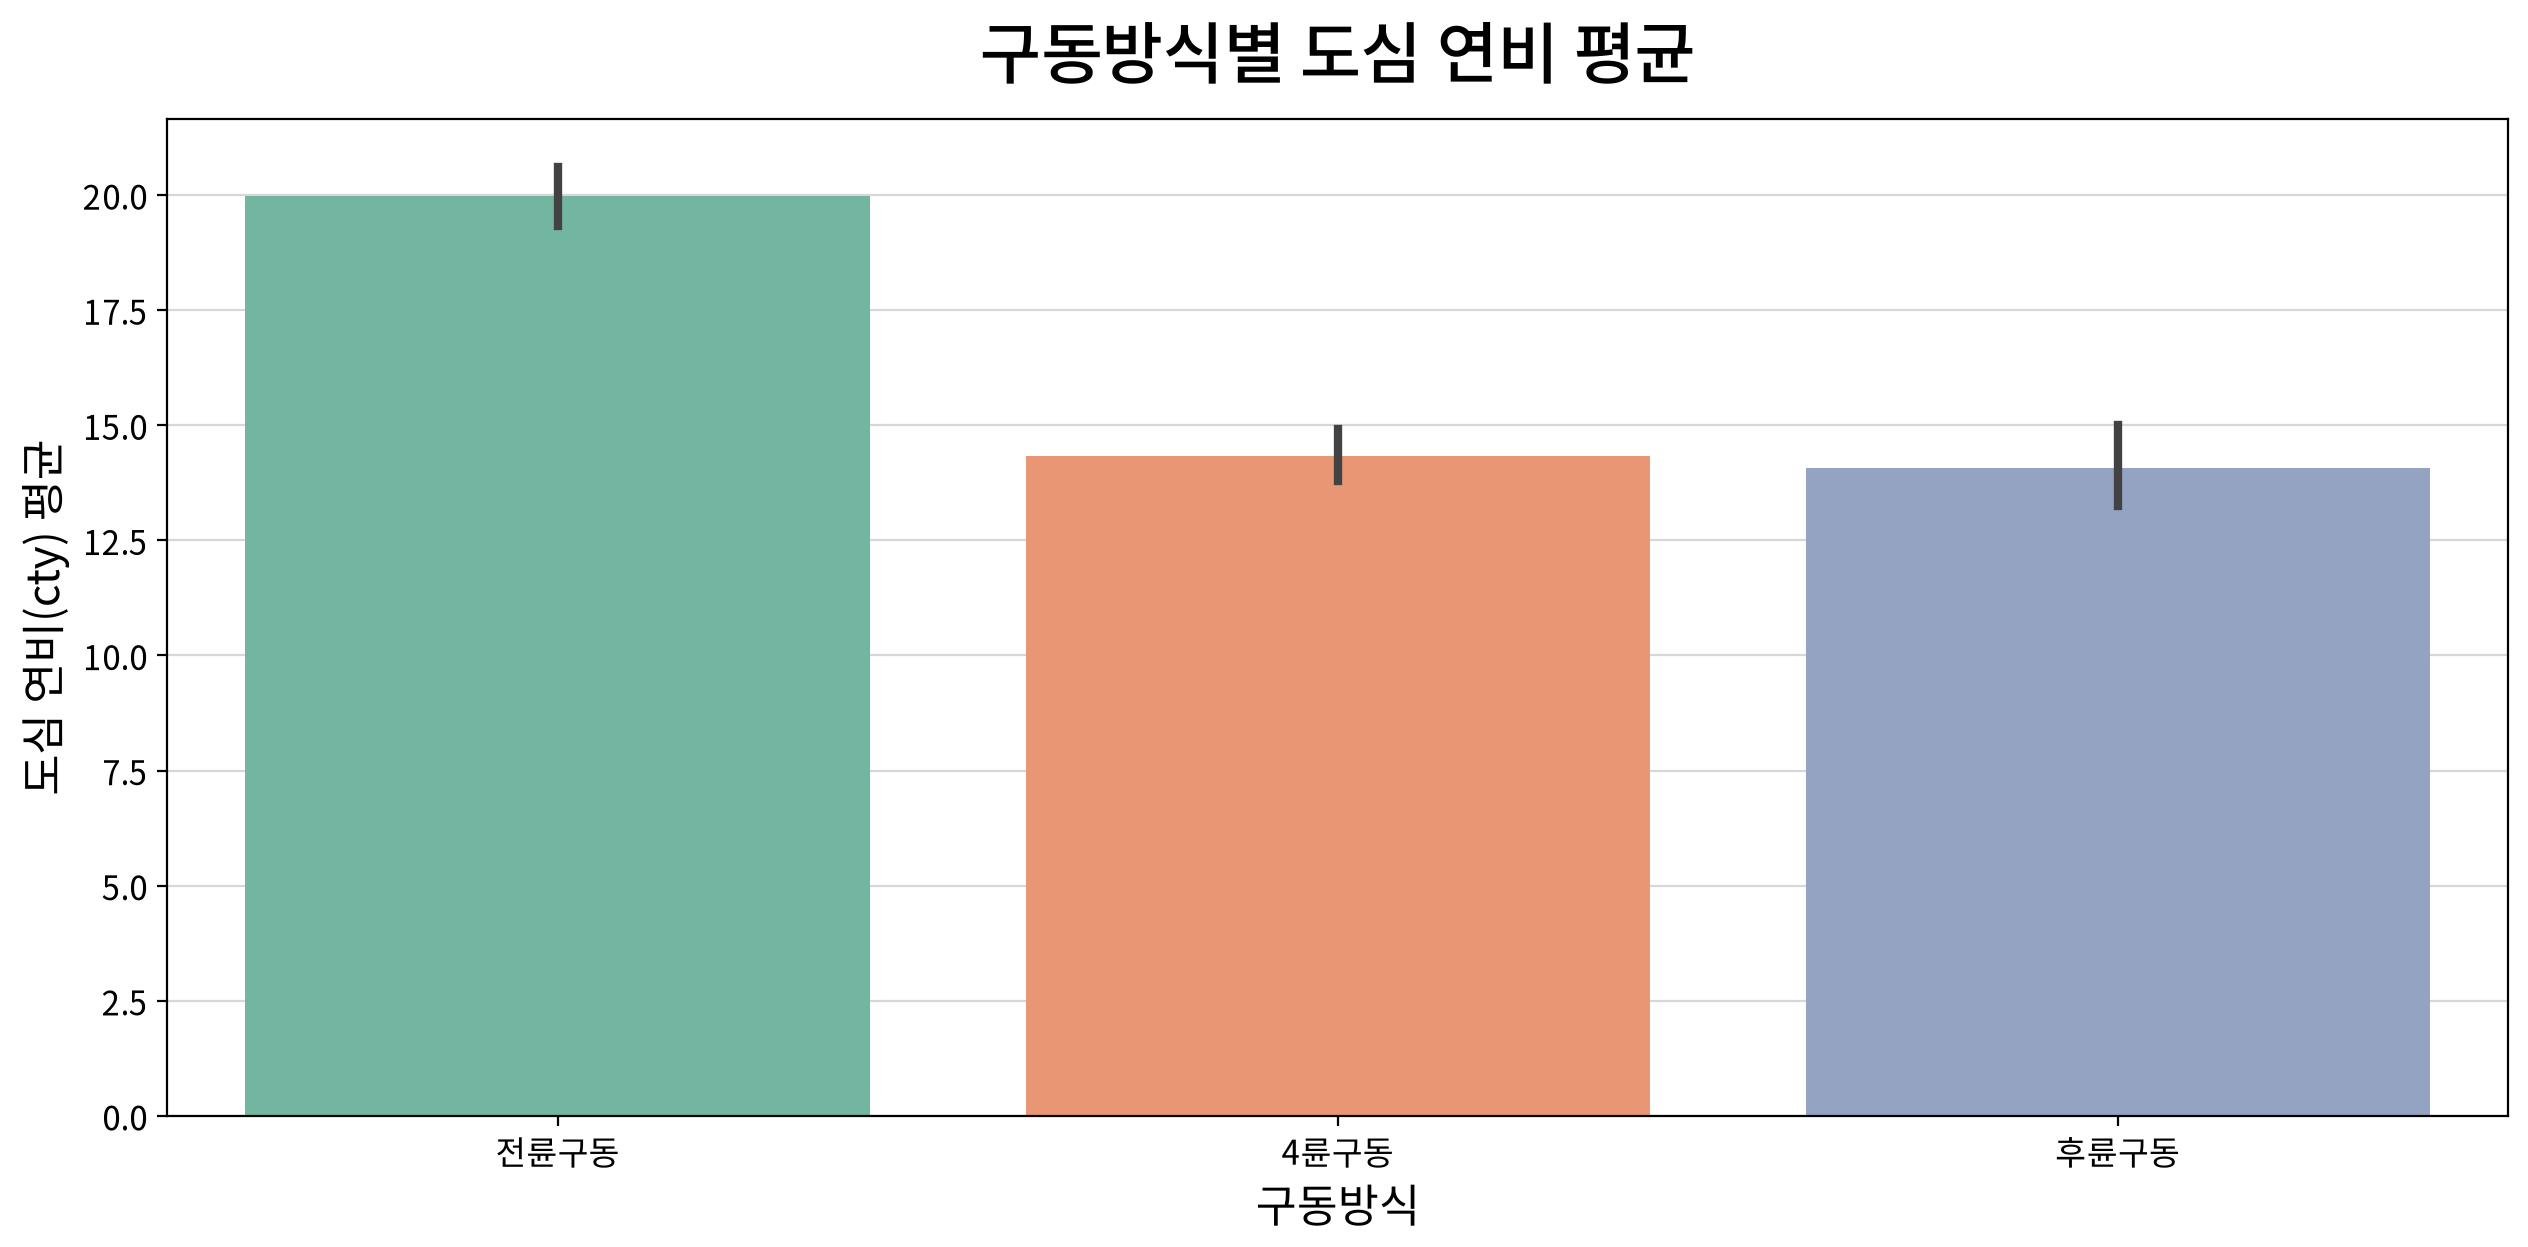

In [10]:
my_plot.barplot(data=df, x="drv", y="cty", estimator="mean", hue="drv", palette="Set2",
                title="구동방식별 도심 연비 평균", xlabel="구동방식", ylabel="도심 연비(cty) 평균")

## 문제 5. 실린더 수(`cyl`)가 많아질수록 고속도로 연비(`hwy`)는 어떤 경향을 보이는가?

① 증가한다  ② 감소한다  ③ 관계가 없다  ④ U자 형태

> 💡 **힌트**: 막대그래프 (실린더 수별 hwy 평균)

### 정답 및 해설

**정답: ② 감소한다**

실린더별 고속도로 연비 평균은 4기통 28.8, 5기통 28.75, 6기통 22.82, 8기통 17.63으로, 실린더가 많아질수록 연비가 뚜렷하게 낮아집니다.


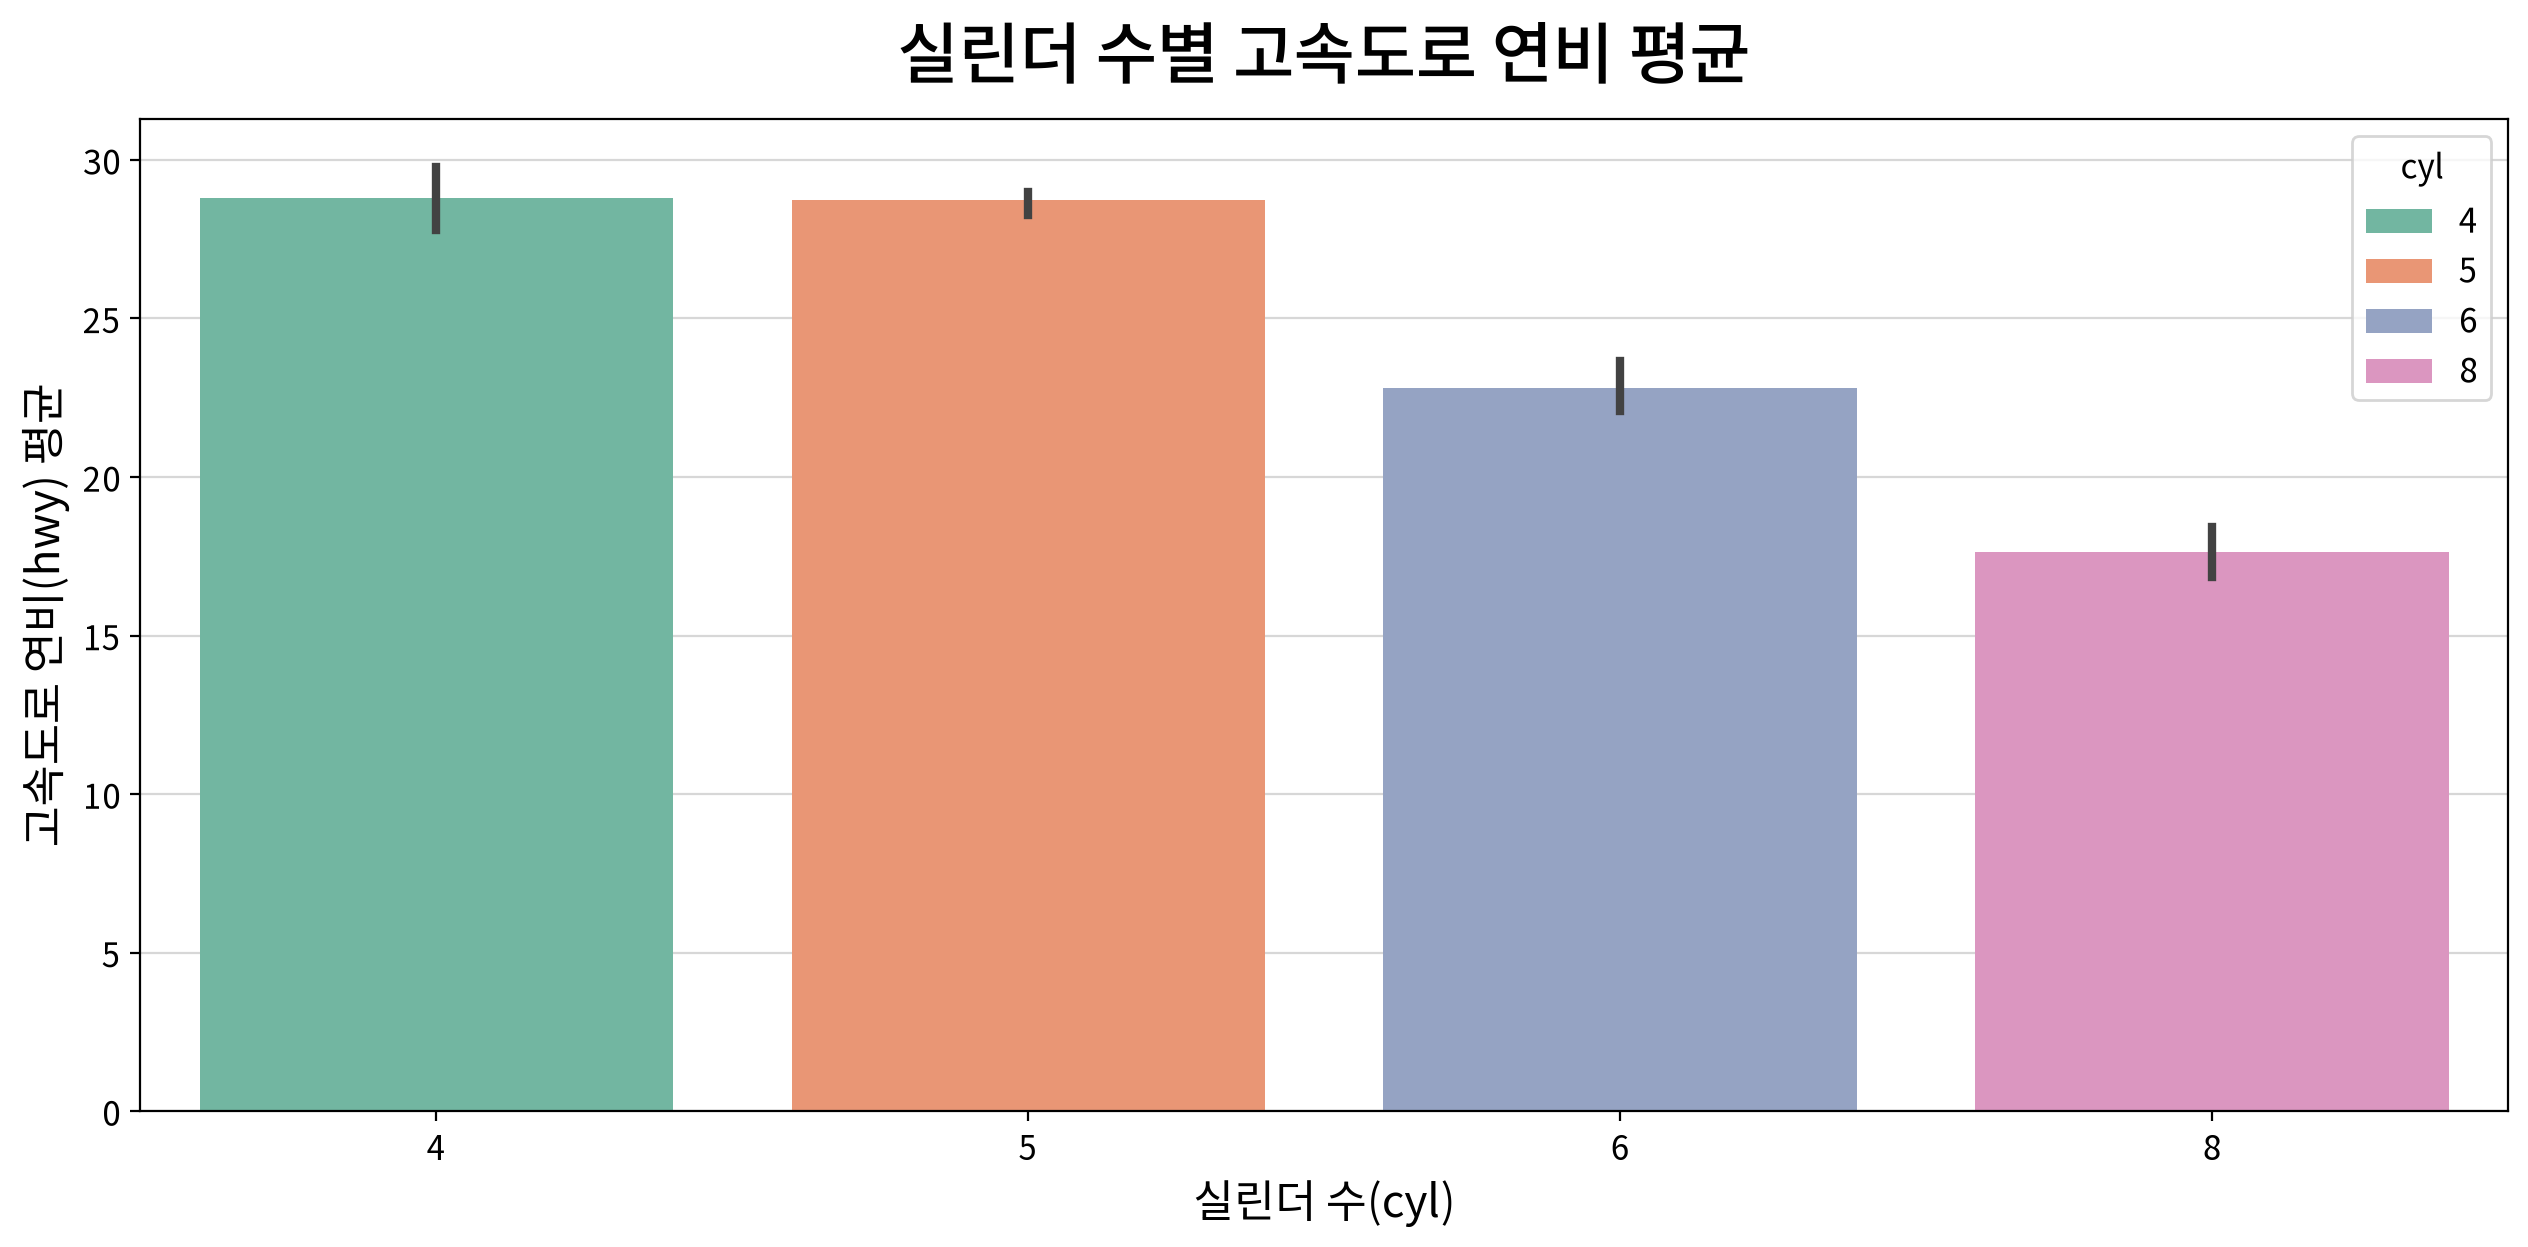

In [11]:
my_plot.barplot(data=df, x="cyl", y="hwy", 
                estimator="mean", hue="cyl", palette="Set2",
                title="실린더 수별 고속도로 연비 평균", 
                xlabel="실린더 수(cyl)", ylabel="고속도로 연비(hwy) 평균")

## 문제 6. 배기량(`displ`)과 고속도로 연비(`hwy`)는 어떤 상관관계를 가지는가?

① 양(+)의 상관  ② 음(−)의 상관  ③ 상관 없음  ④ 곡선(2차) 관계

> 💡 **힌트**: 산점도 (+ 추세선)

### 정답 및 해설

**정답: ② 음(−)의 상관**

산점도와 추세선을 그리면 우하향하며, 상관계수는 약 −0.77입니다. 배기량이 클수록 연비가 낮아집니다.


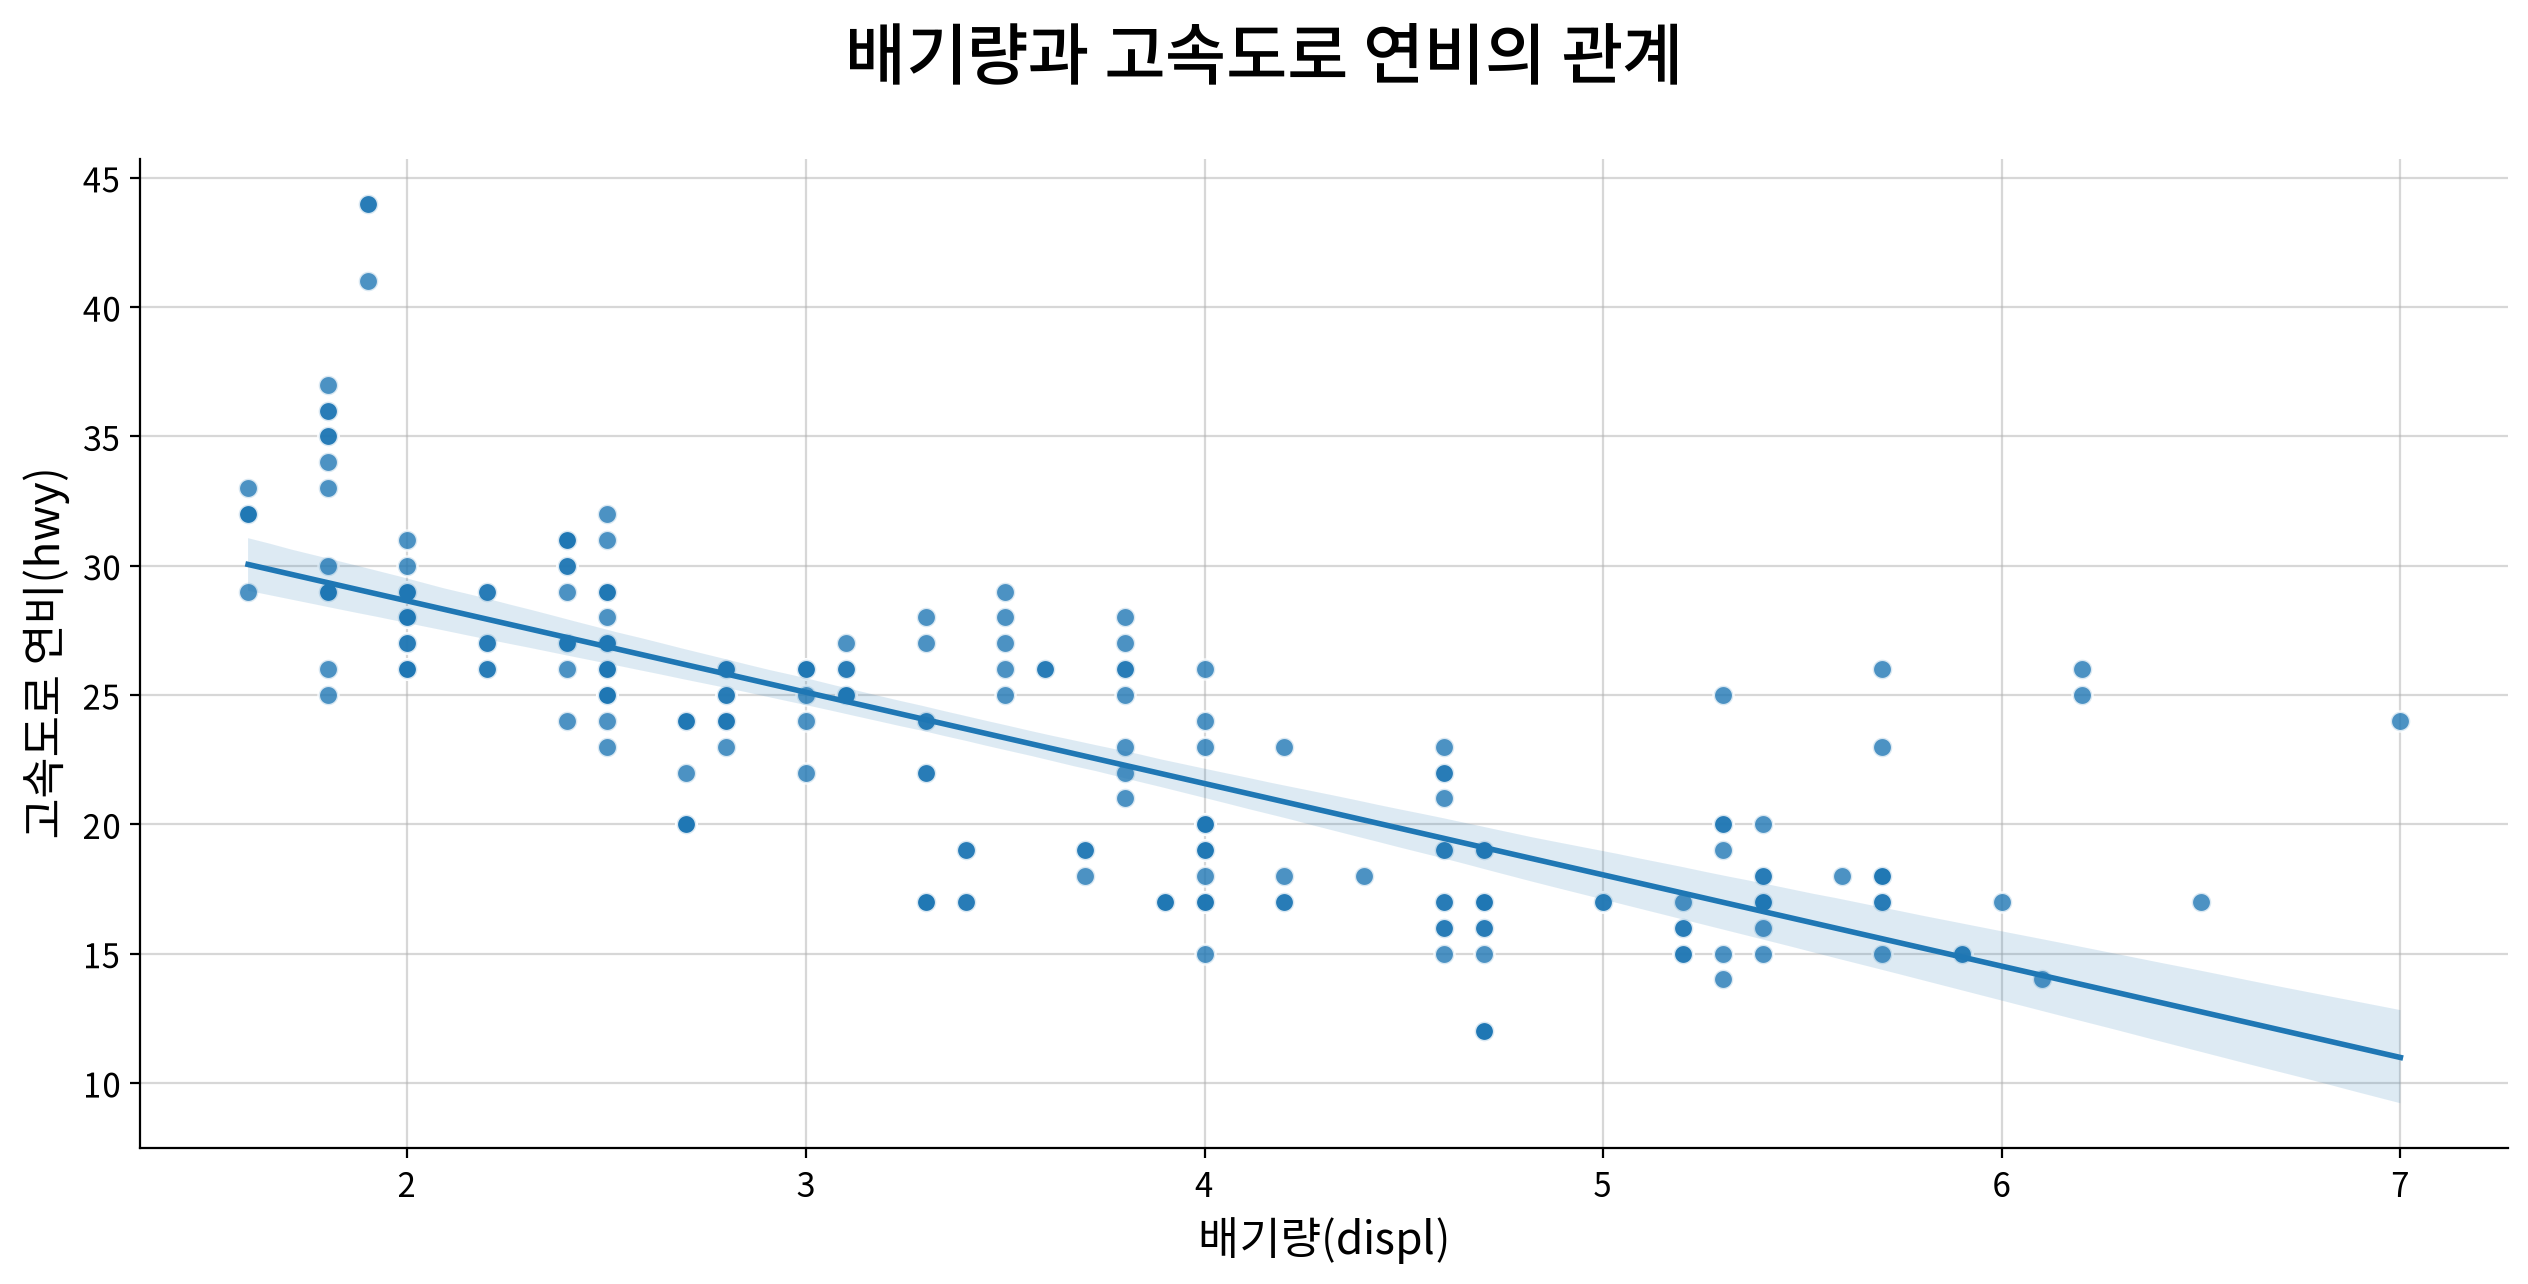

In [12]:
my_plot.lmplot(data=df, x="displ", y="hwy", title="배기량과 고속도로 연비의 관계", xlabel="배기량(displ)", ylabel="고속도로 연비(hwy)")

## 문제 7. 배기량(`displ`)과 더 강한(추세션의 기울기가 큰) 상관관계를 가지는 연비는?

① 도심 연비(cty)  ② 고속도로 연비(hwy)  ③ 둘이 완전히 동일  ④ 둘 다 상관 없음

> 💡 **힌트**: 산점도 2개를 비교 (+ 추세선)

### 정답 및 해설

**정답: ② 고속도로 연비(hwy)**

고속도로 연비가 더 기울기가 큽니다.


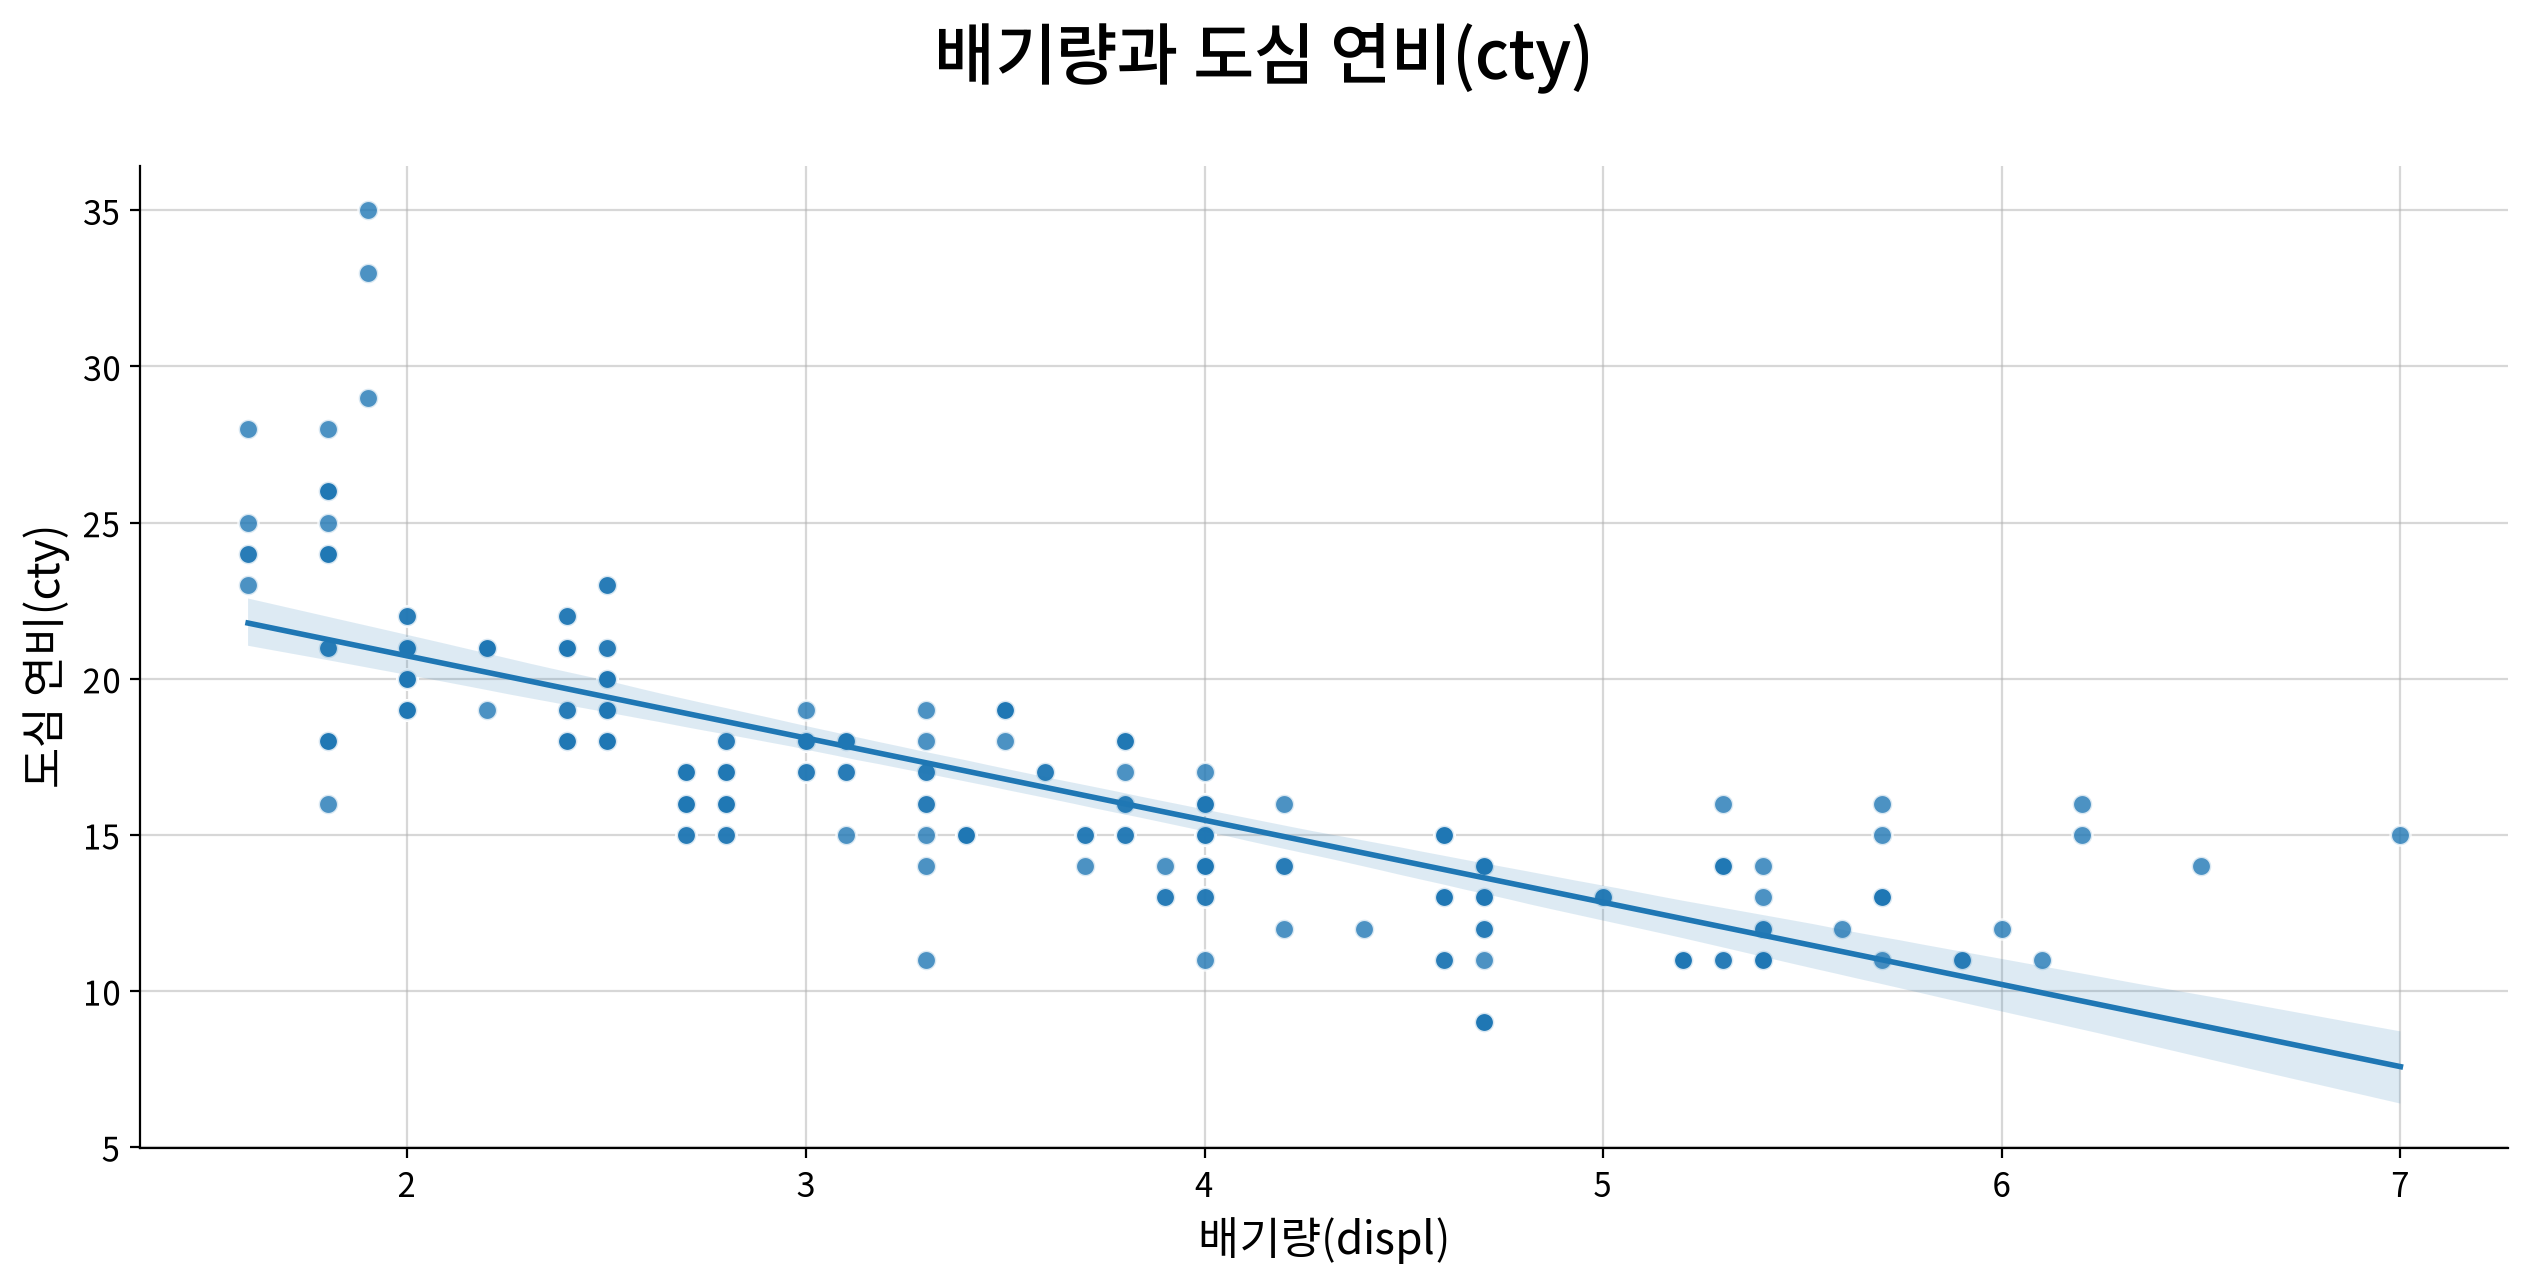

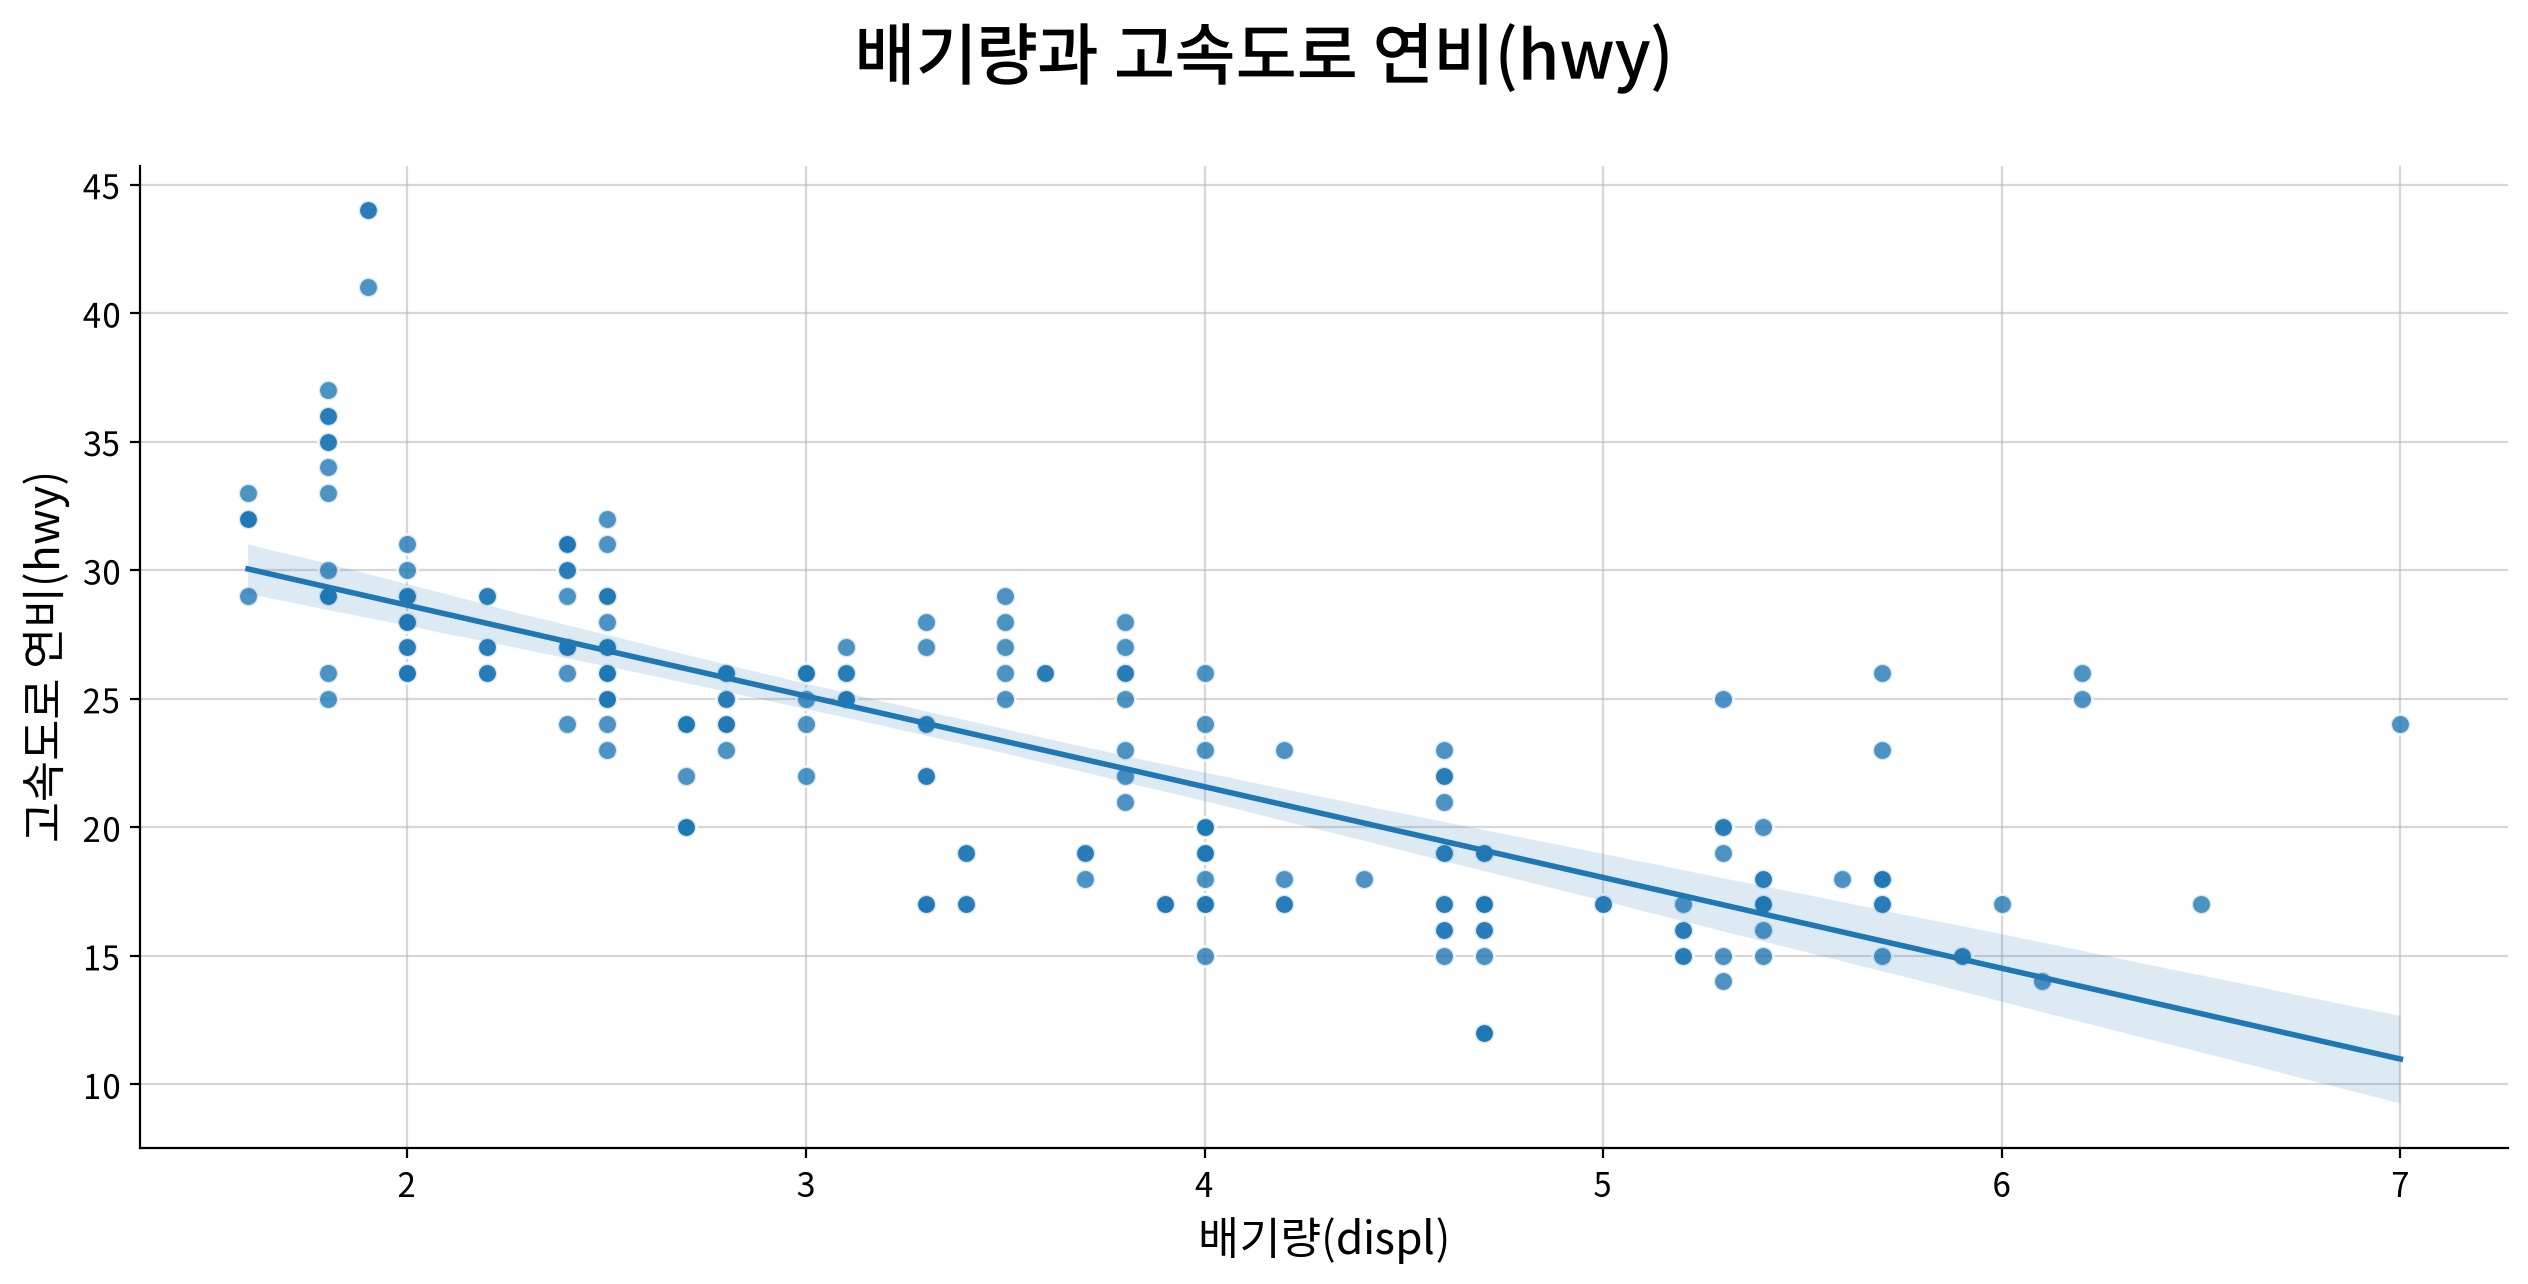

In [13]:
# (1) 배기량 - 도심 연비
my_plot.lmplot(data=df, x="displ", y="cty",
               title="배기량과 도심 연비(cty)", 
               xlabel="배기량(displ)", ylabel="도심 연비(cty)")

# (2) 배기량 - 고속도로 연비
my_plot.lmplot(data=df, x="displ", y="hwy",
               title="배기량과 고속도로 연비(hwy)", 
               xlabel="배기량(displ)", ylabel="고속도로 연비(hwy)")

## 문제 8. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 낮은 종류는?

① suv  ② pickup  ③ minivan  ④ midsize

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균)

### 정답 및 해설

**정답: ② pickup**

차종별 고속도로 연비 평균은 pickup 16.88, suv 18.13, minivan 22.36, 2seater 24.8, midsize 27.29, subcompact 28.14, compact 28.30입니다. pickup이 가장 낮습니다.


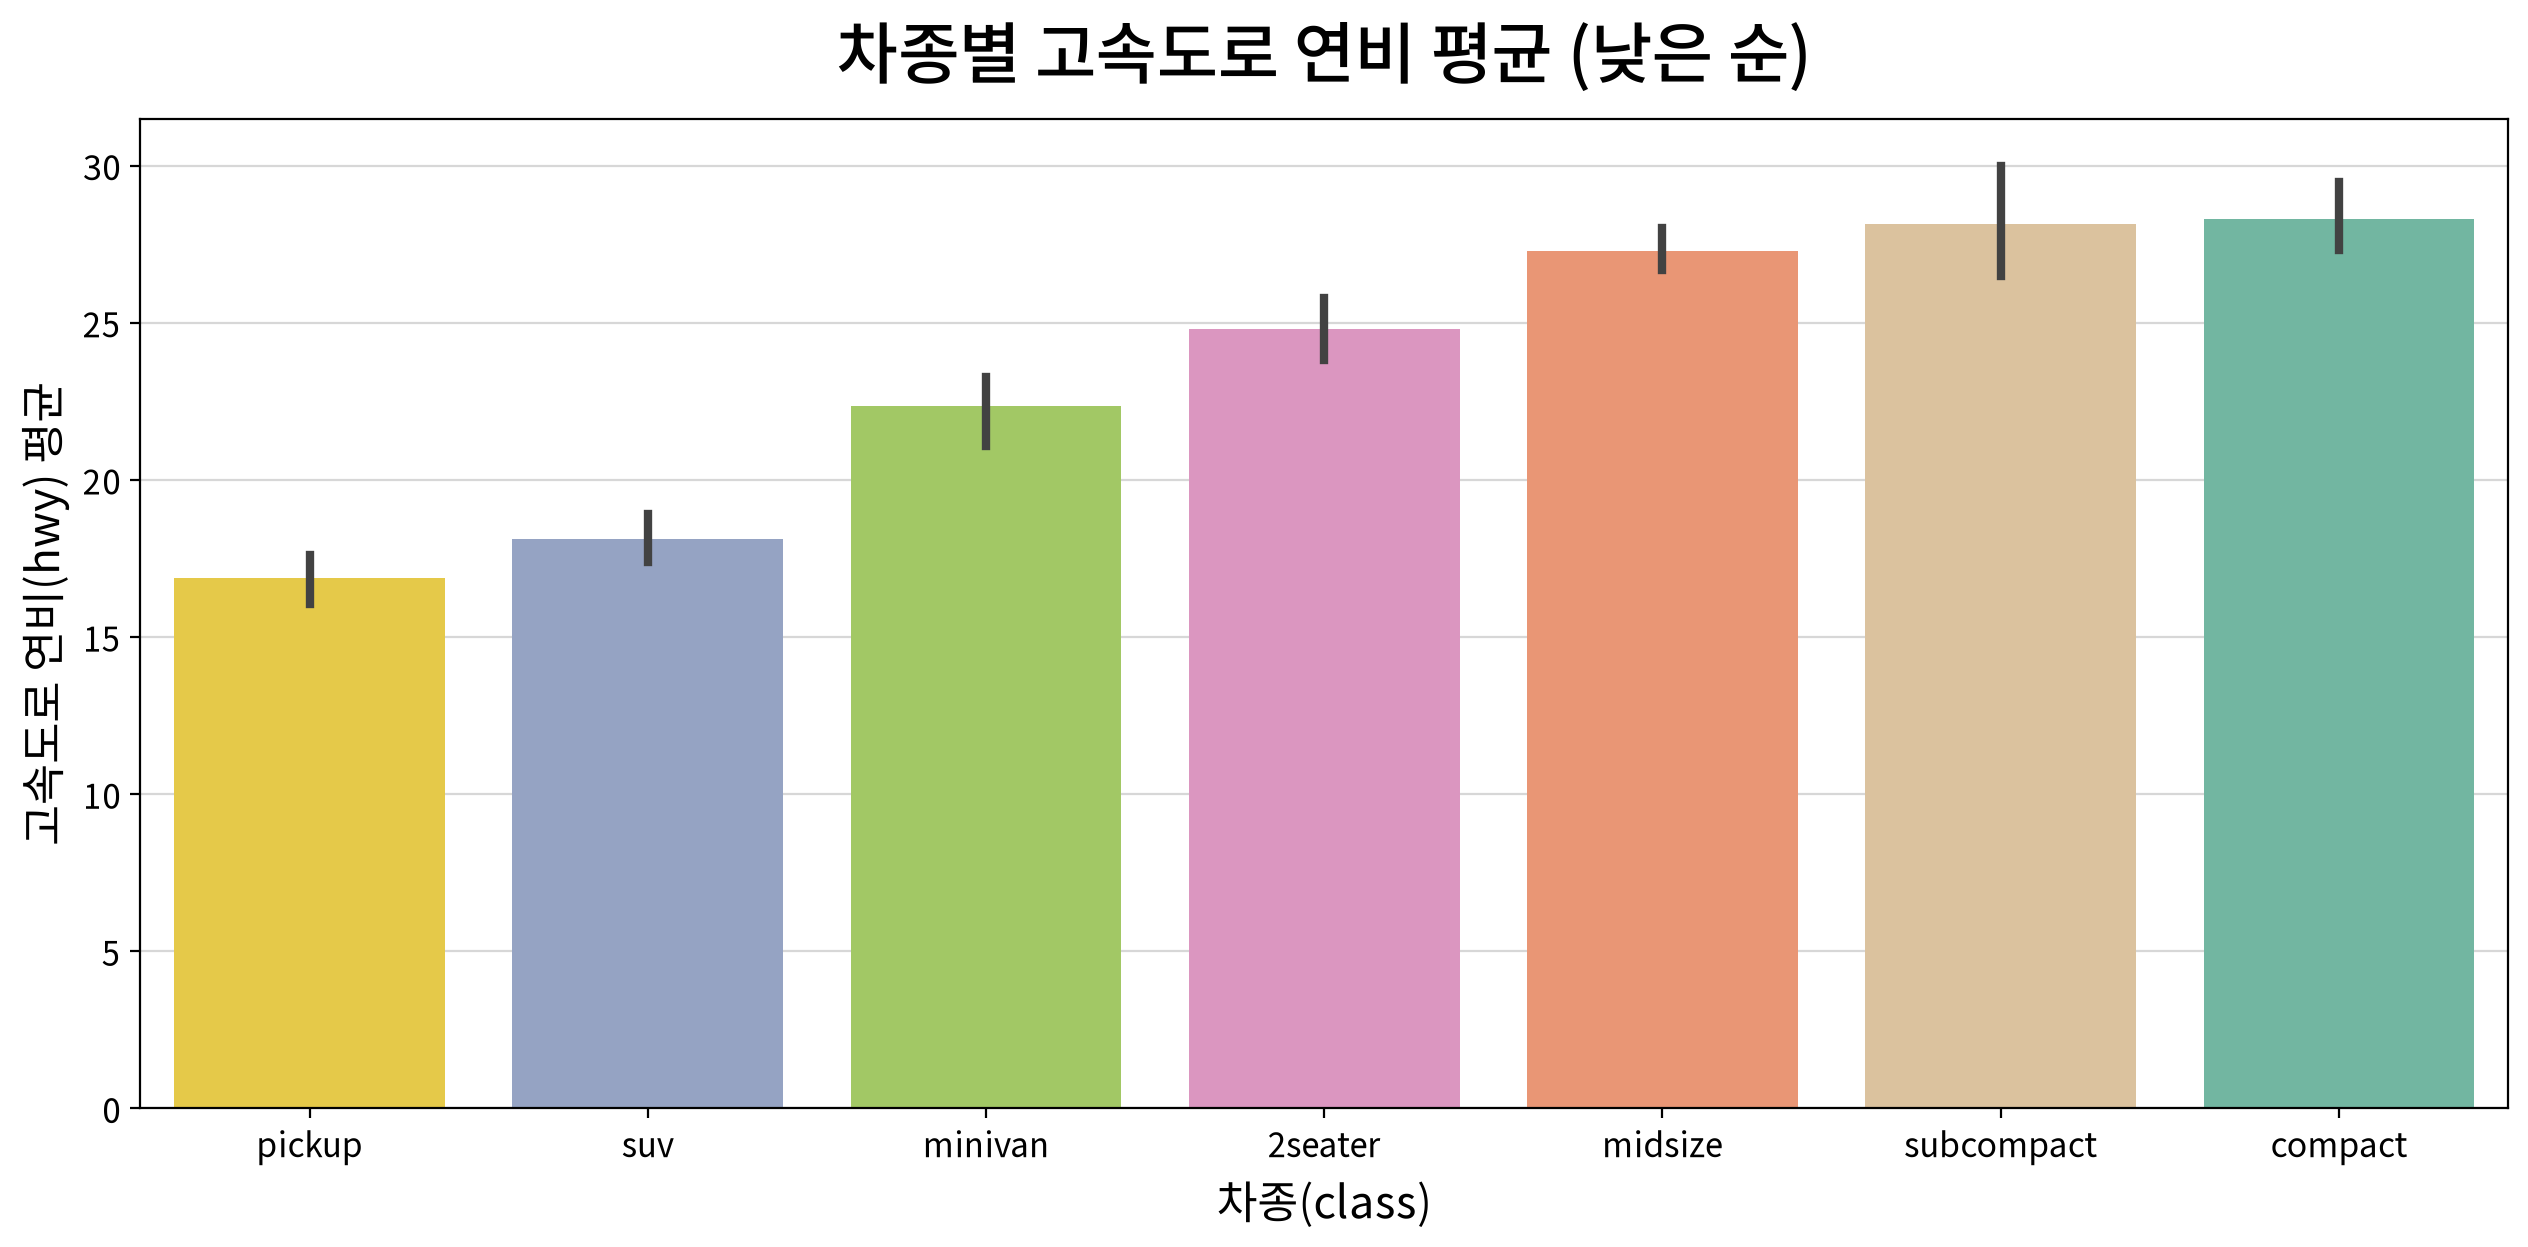

In [14]:
sorted = df.groupby("class")["hwy"].mean().sort_values(ascending=True)

my_plot.barplot(data=df, x="class", y="hwy", estimator="mean", hue="class", palette="Set2", order=sorted.index, title="차종별 고속도로 연비 평균 (낮은 순)", xlabel="차종(class)", ylabel="고속도로 연비(hwy) 평균")

## 문제 9. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 높은 종류는?

① compact  ② subcompact  ③ midsize  ④ 2seater

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균, 내림차순 정렬)

### 정답 및 해설

**정답: ① compact**

compact 28.30, subcompact 28.14로 매우 근소하지만 compact가 가장 높습니다. 정렬된 막대그래프로 1·2위를 비교해야 구분됩니다.


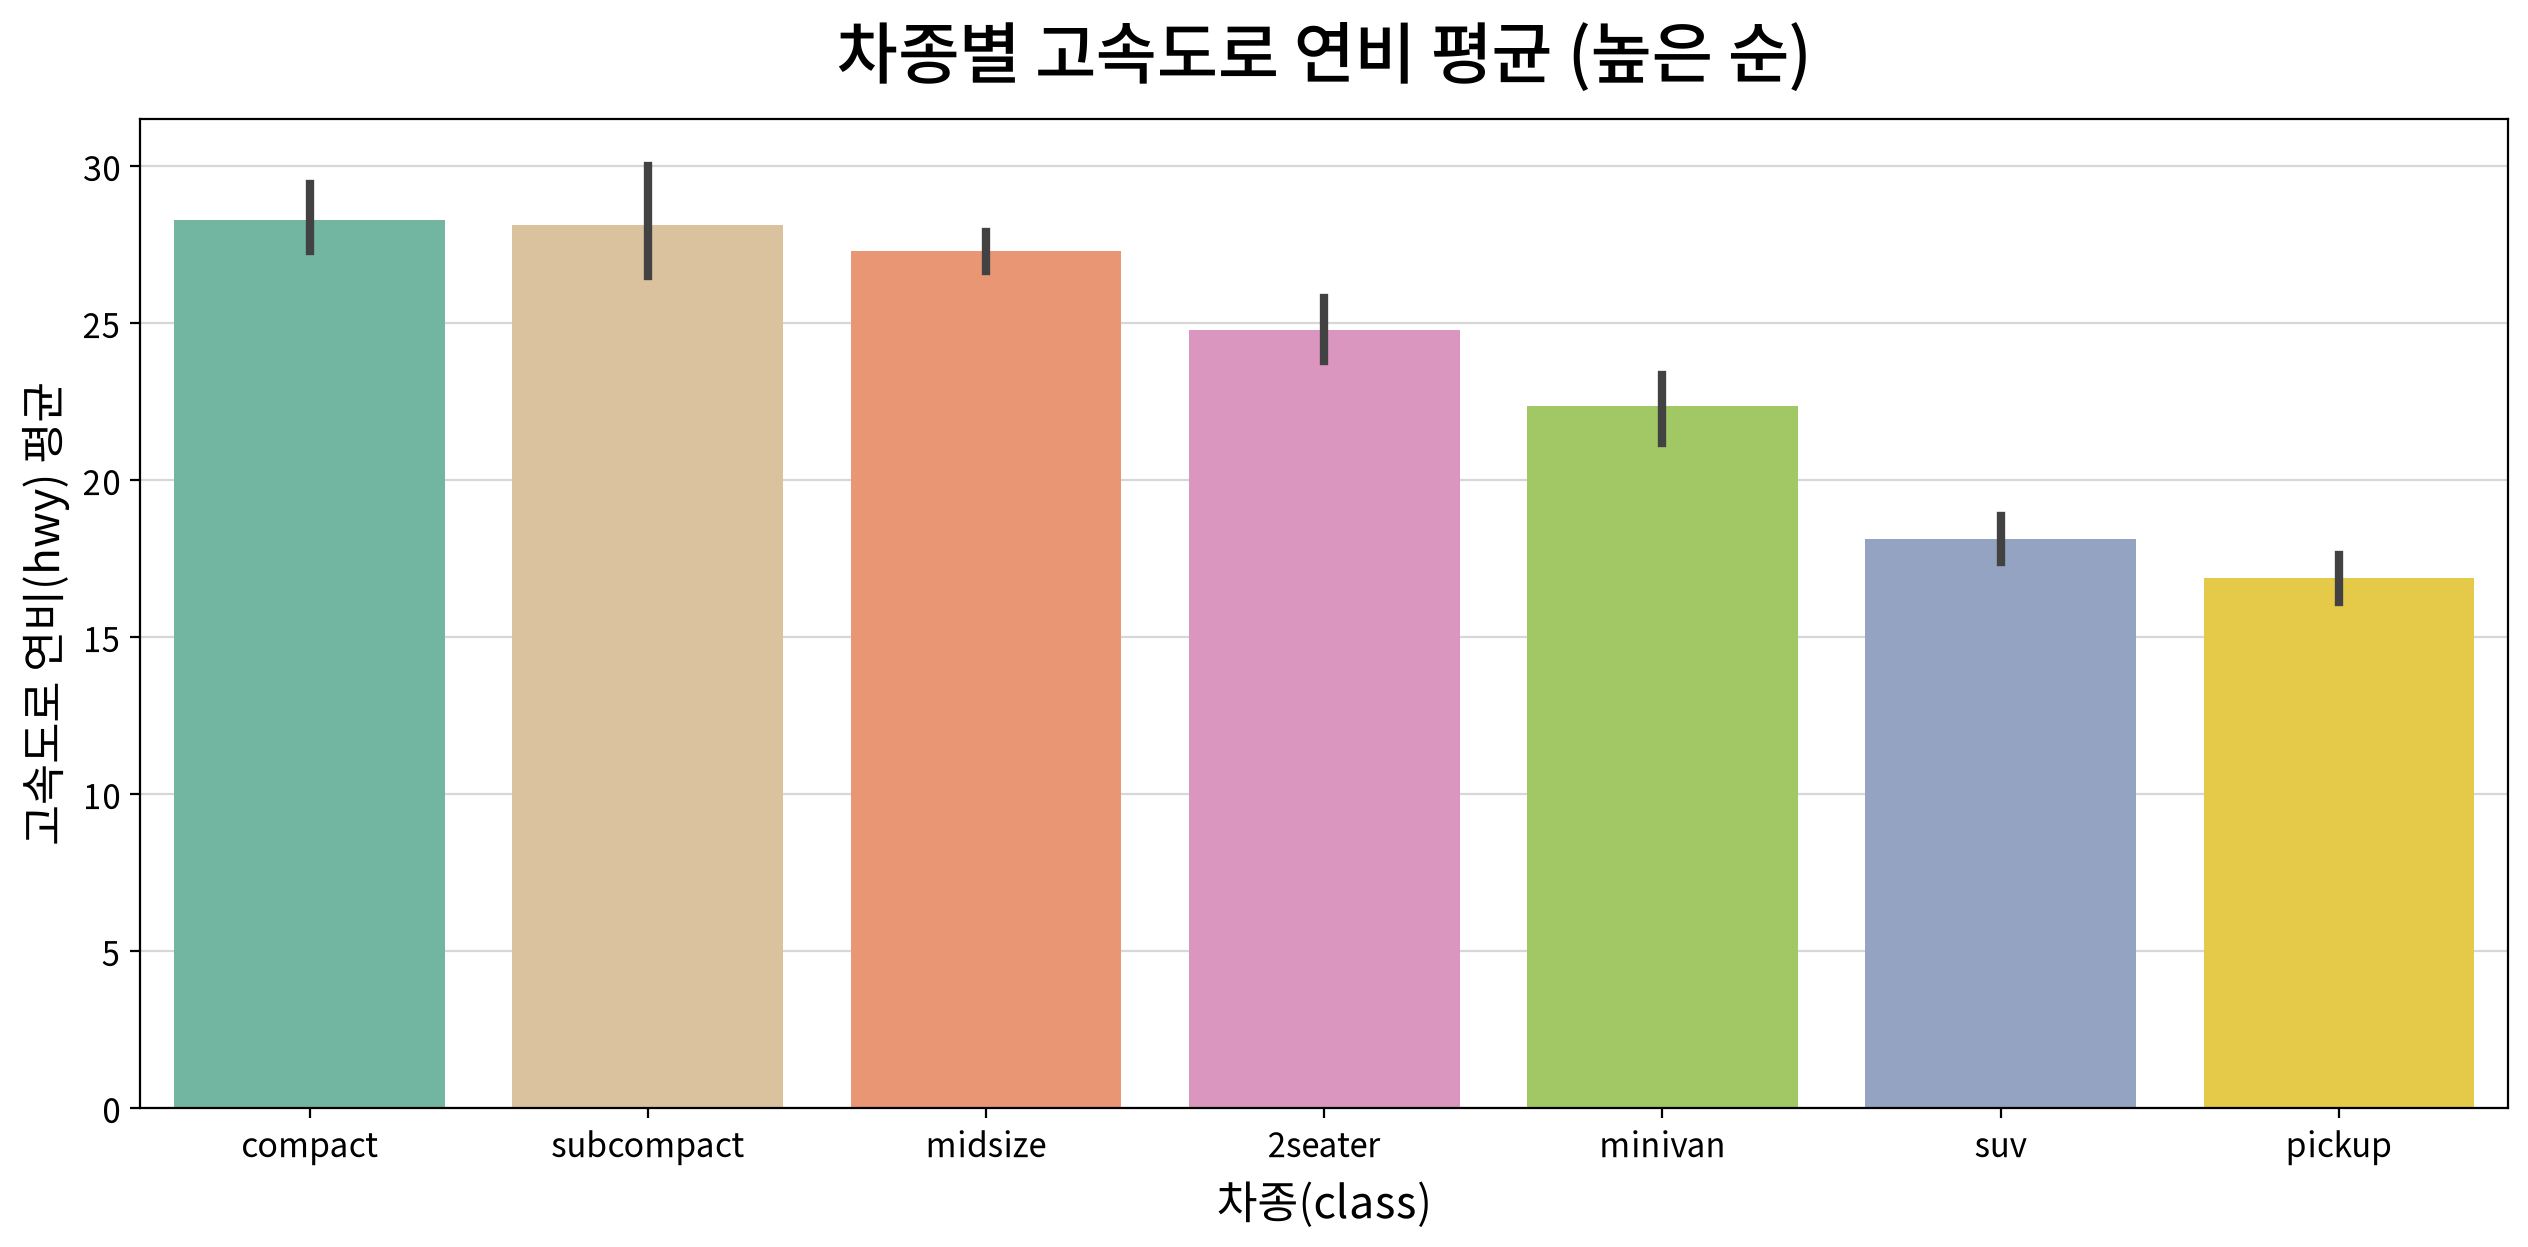

In [15]:
sorted = df.groupby("class")["hwy"].mean().sort_values(ascending=False)

my_plot.barplot(data=df, x="class", y="hwy", estimator="mean", hue="class", palette="Set2", order=sorted.index, title="차종별 고속도로 연비 평균 (높은 순)", xlabel="차종(class)", ylabel="고속도로 연비(hwy) 평균")

## 문제 10. 도심 연비(`cty`) 평균이 가장 높은 제조사는?

① volkswagen  ② honda  ③ subaru  ④ hyundai

> 💡 **힌트**: 막대그래프 (제조사별 cty 평균)

### 정답 및 해설

**정답: ② honda**

제조사별 도심 연비 평균은 honda 24.44로 가장 높고, 그 뒤로 volkswagen 20.93, subaru 19.29, hyundai 18.64 순입니다.


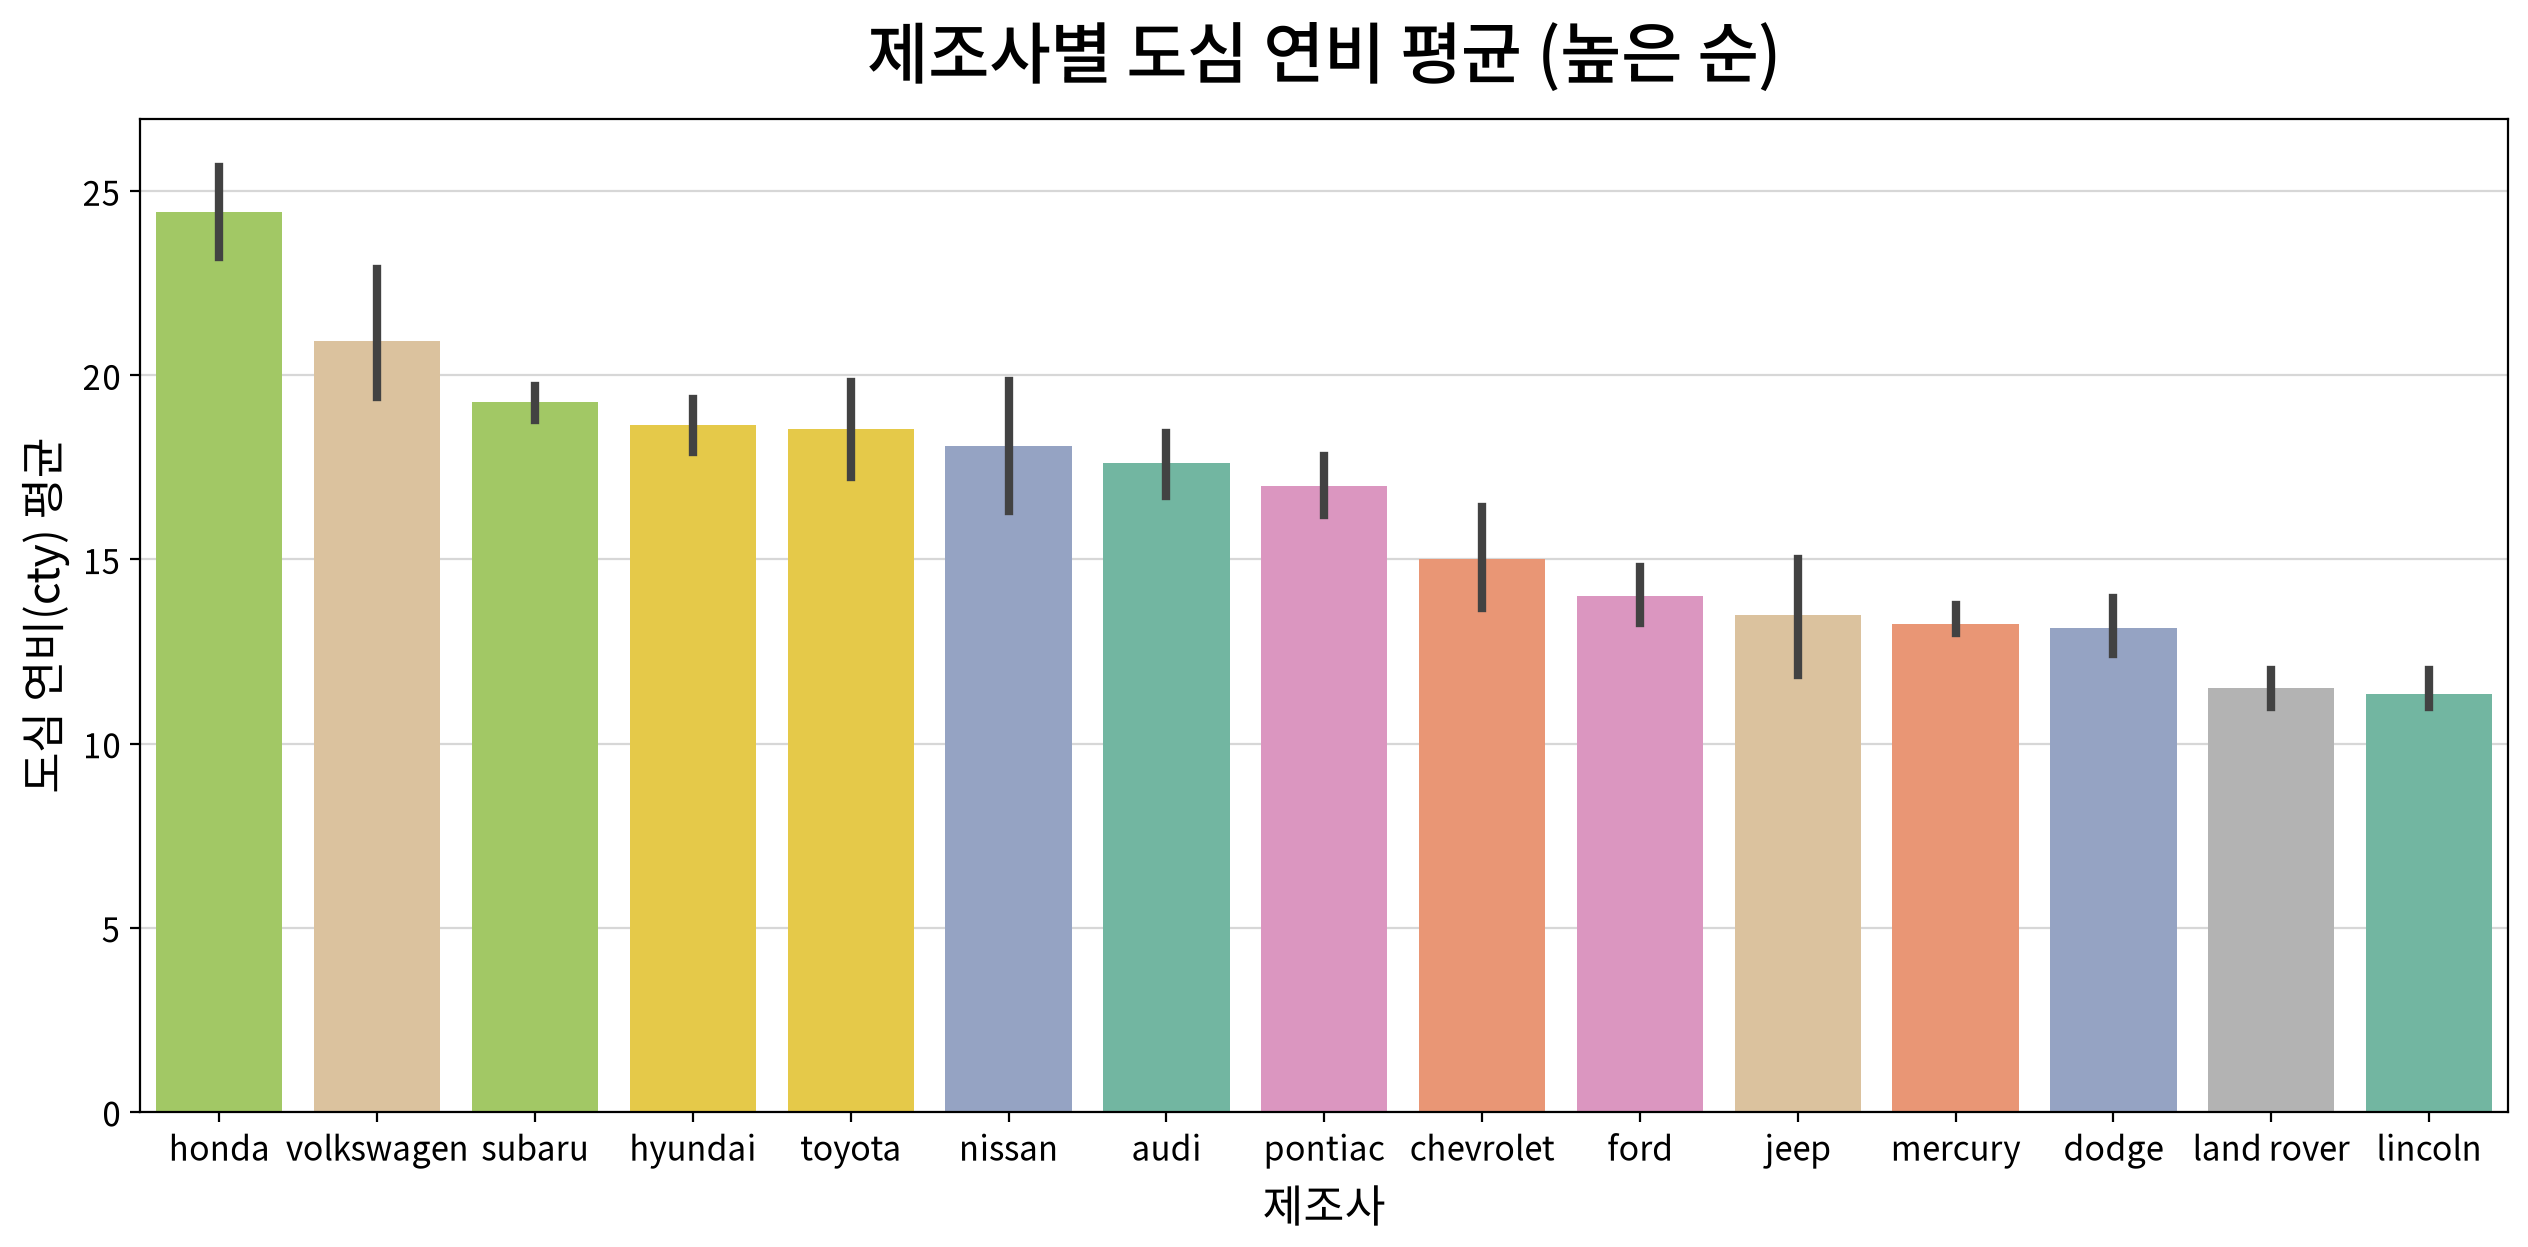

In [16]:
sorted = df.groupby("manufacturer")["cty"].mean().sort_values(ascending=False)

my_plot.barplot(data=df, x="manufacturer", y="cty",
                estimator="mean", hue="manufacturer", palette="Set2",
                order=sorted.index,
                title="제조사별 도심 연비 평균 (높은 순)", 
                xlabel="제조사", ylabel="도심 연비(cty) 평균")

## 문제 11. 고속도로 연비(`hwy`) 평균이 가장 낮은 제조사는?

① dodge  ② lincoln  ③ land rover  ④ jeep

> 💡 **힌트**: 막대그래프 (제조사별 hwy 평균)

### 정답 및 해설

**정답: ③ land rover**

제조사별 고속도로 연비 평균은 land rover 16.50으로 가장 낮고, jeep 17.62, dodge 17.95, lincoln 17.00 등이 뒤를 잇습니다. (lincoln 17.0, land rover 16.5 — land rover가 더 낮음)


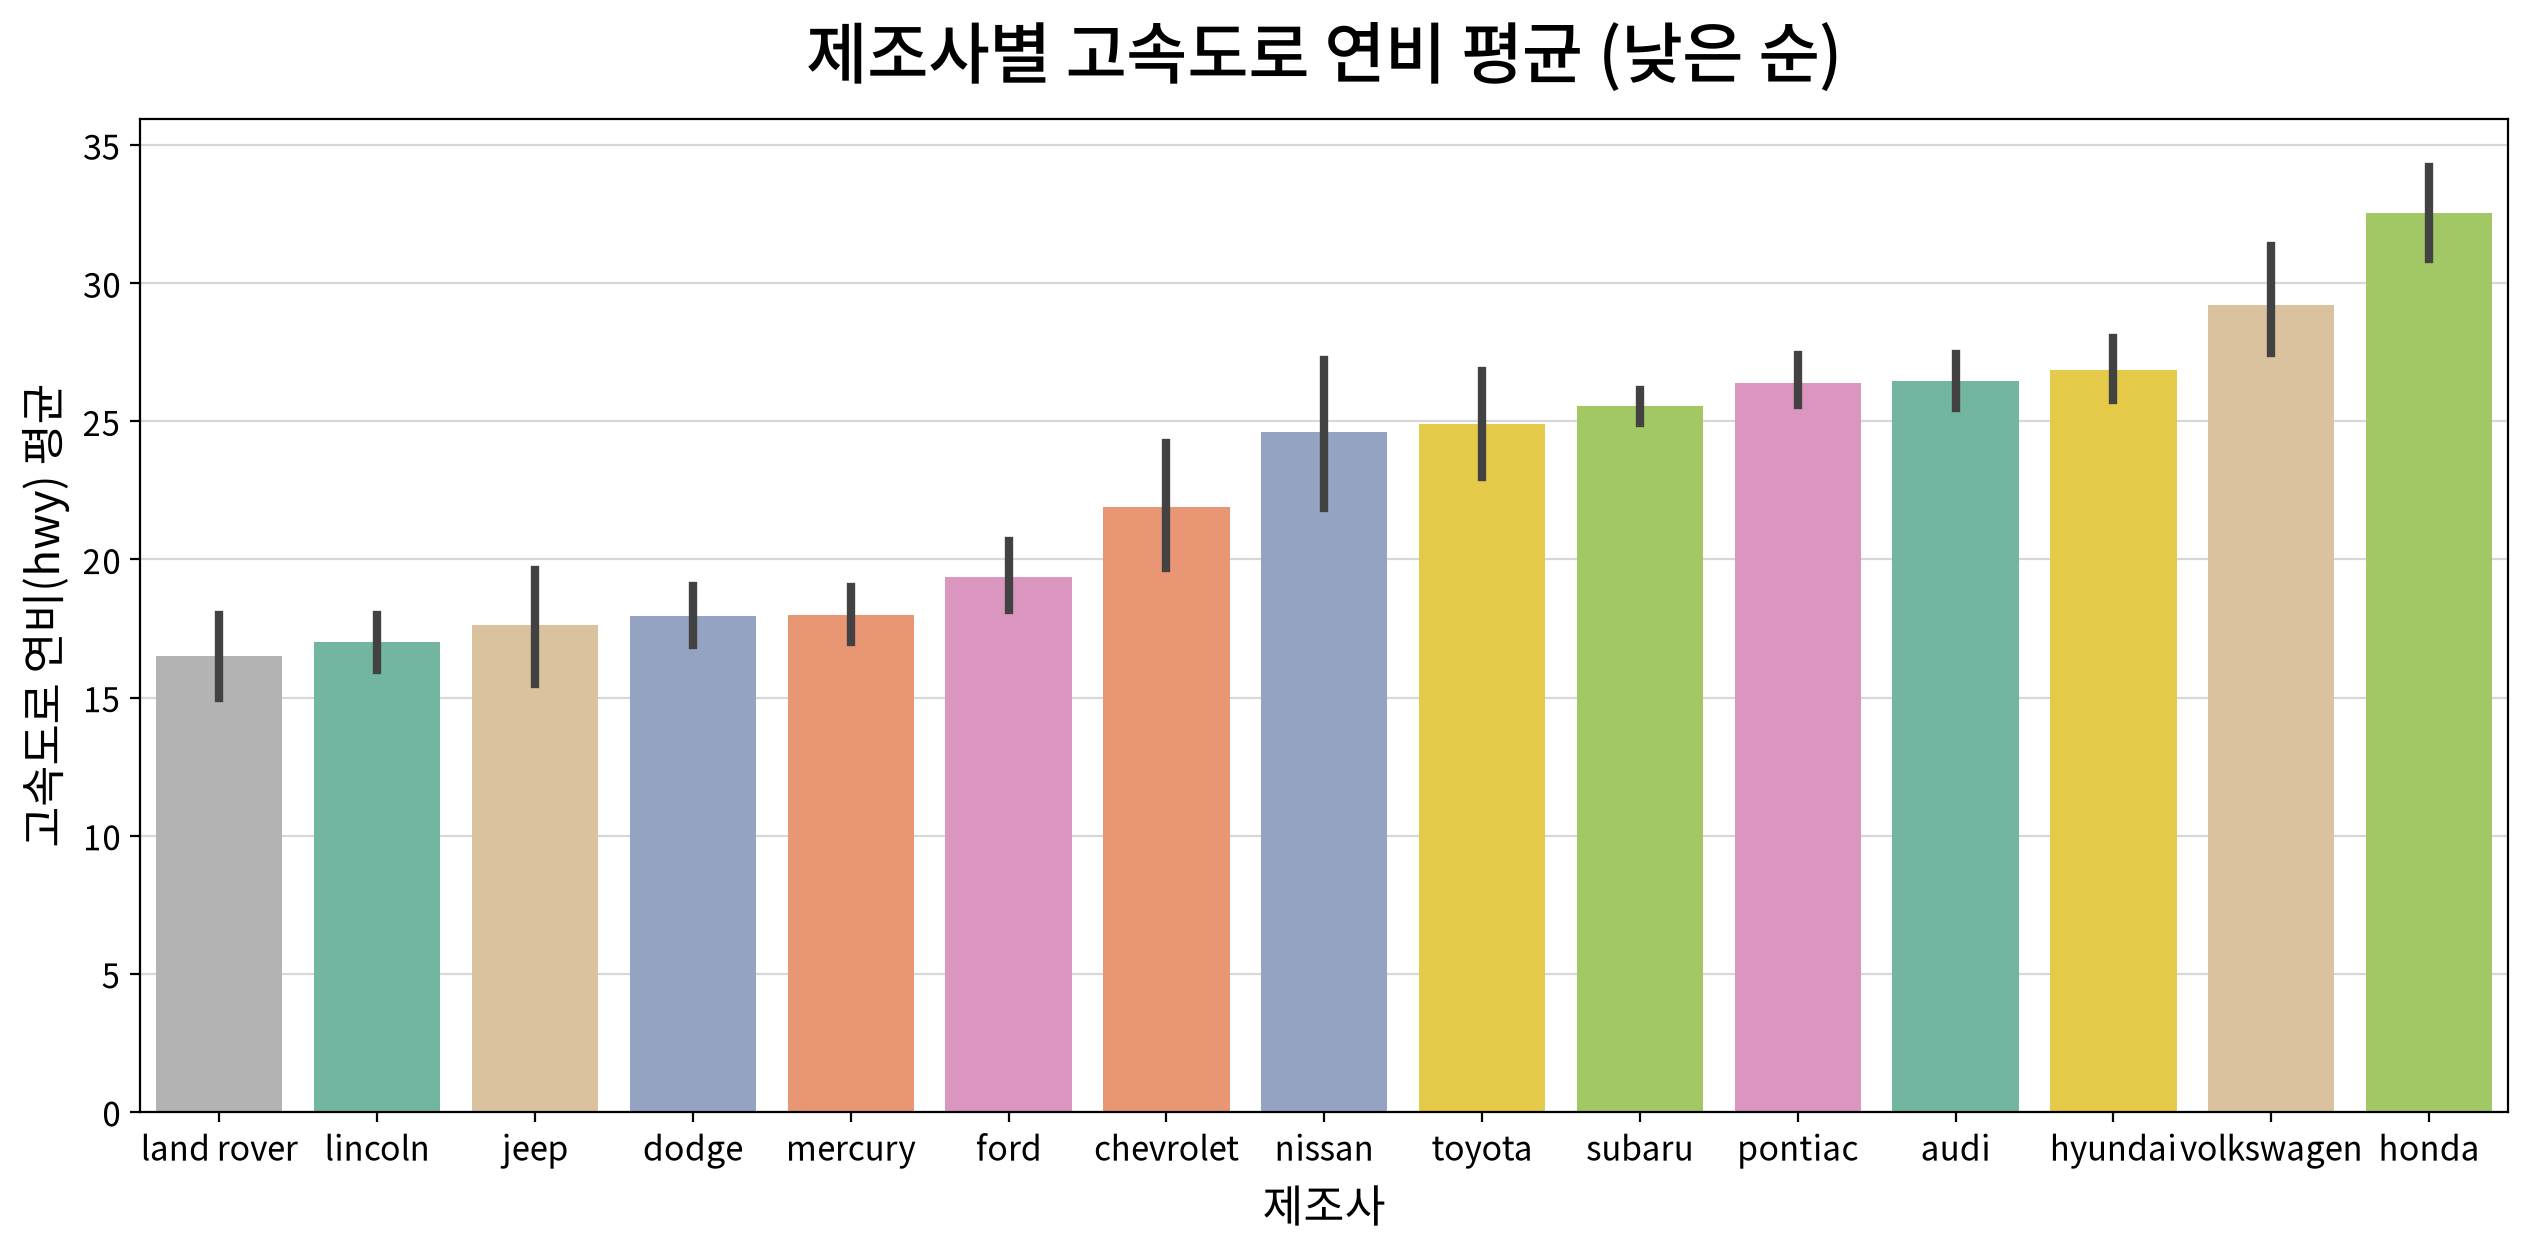

In [17]:
sorted = df.groupby("manufacturer")["hwy"].mean().sort_values(ascending=True)

my_plot.barplot(data=df, x="manufacturer", y="hwy",
                estimator="mean", hue="manufacturer", palette="Set2",
                order=sorted.index,
                title="제조사별 고속도로 연비 평균 (낮은 순)", 
                xlabel="제조사", ylabel="고속도로 연비(hwy) 평균")

## 문제 12. 변속기 종류(자동 vs 수동)에 따른 연비 비교로 옳은 것은?

① 자동이 수동보다 연비가 높다  ② 수동이 자동보다 연비가 높다  ③ 차이가 없다  ④ 도심은 자동, 고속도로는 수동이 높다

> 💡 **힌트**: 막대그래프 (`trans`를 auto/manual로 묶은 뒤 cty·hwy 평균)

### 정답 및 해설

**정답: ② 수동이 자동보다 연비가 높다**

`trans` 값이 `auto...`인지 `manual...`인지로 그룹화하면, 자동(cty 15.97 / hwy 22.29)보다 수동(cty 18.68 / hwy 25.78)이 도심·고속도로 모두 높습니다.


### 1. 변속기 종류 확인

In [18]:
df['trans'].value_counts()

trans
auto(l4)      83
manual(m5)    58
auto(l5)      39
manual(m6)    19
auto(s6)      16
auto(l6)       6
auto(av)       5
auto(s5)       3
auto(s4)       3
auto(l3)       2
Name: count, dtype: int64

### 2. 변속기 종류에 대한 파생변수 생성

In [19]:
df2 = df.copy()
df2["변속기"] = df2["trans"].str.startswith("auto").map({True: "자동", False: "수동"})
df2.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,변속기
id,,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact,자동
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact,수동
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact,수동
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact,자동
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact,자동


### 3. 변속기 종류에 따른 long 형태로 데이터 재배치

In [20]:
df3 = df2.melt(id_vars="변속기", value_vars=["cty", "hwy"],
                var_name="연비종류", value_name="연비")
df3.head()

,변속기,연비종류,연비
0,자동,cty,18
1,수동,cty,21
2,수동,cty,20
3,자동,cty,21
4,자동,cty,16


### 4. 데이터 시각화

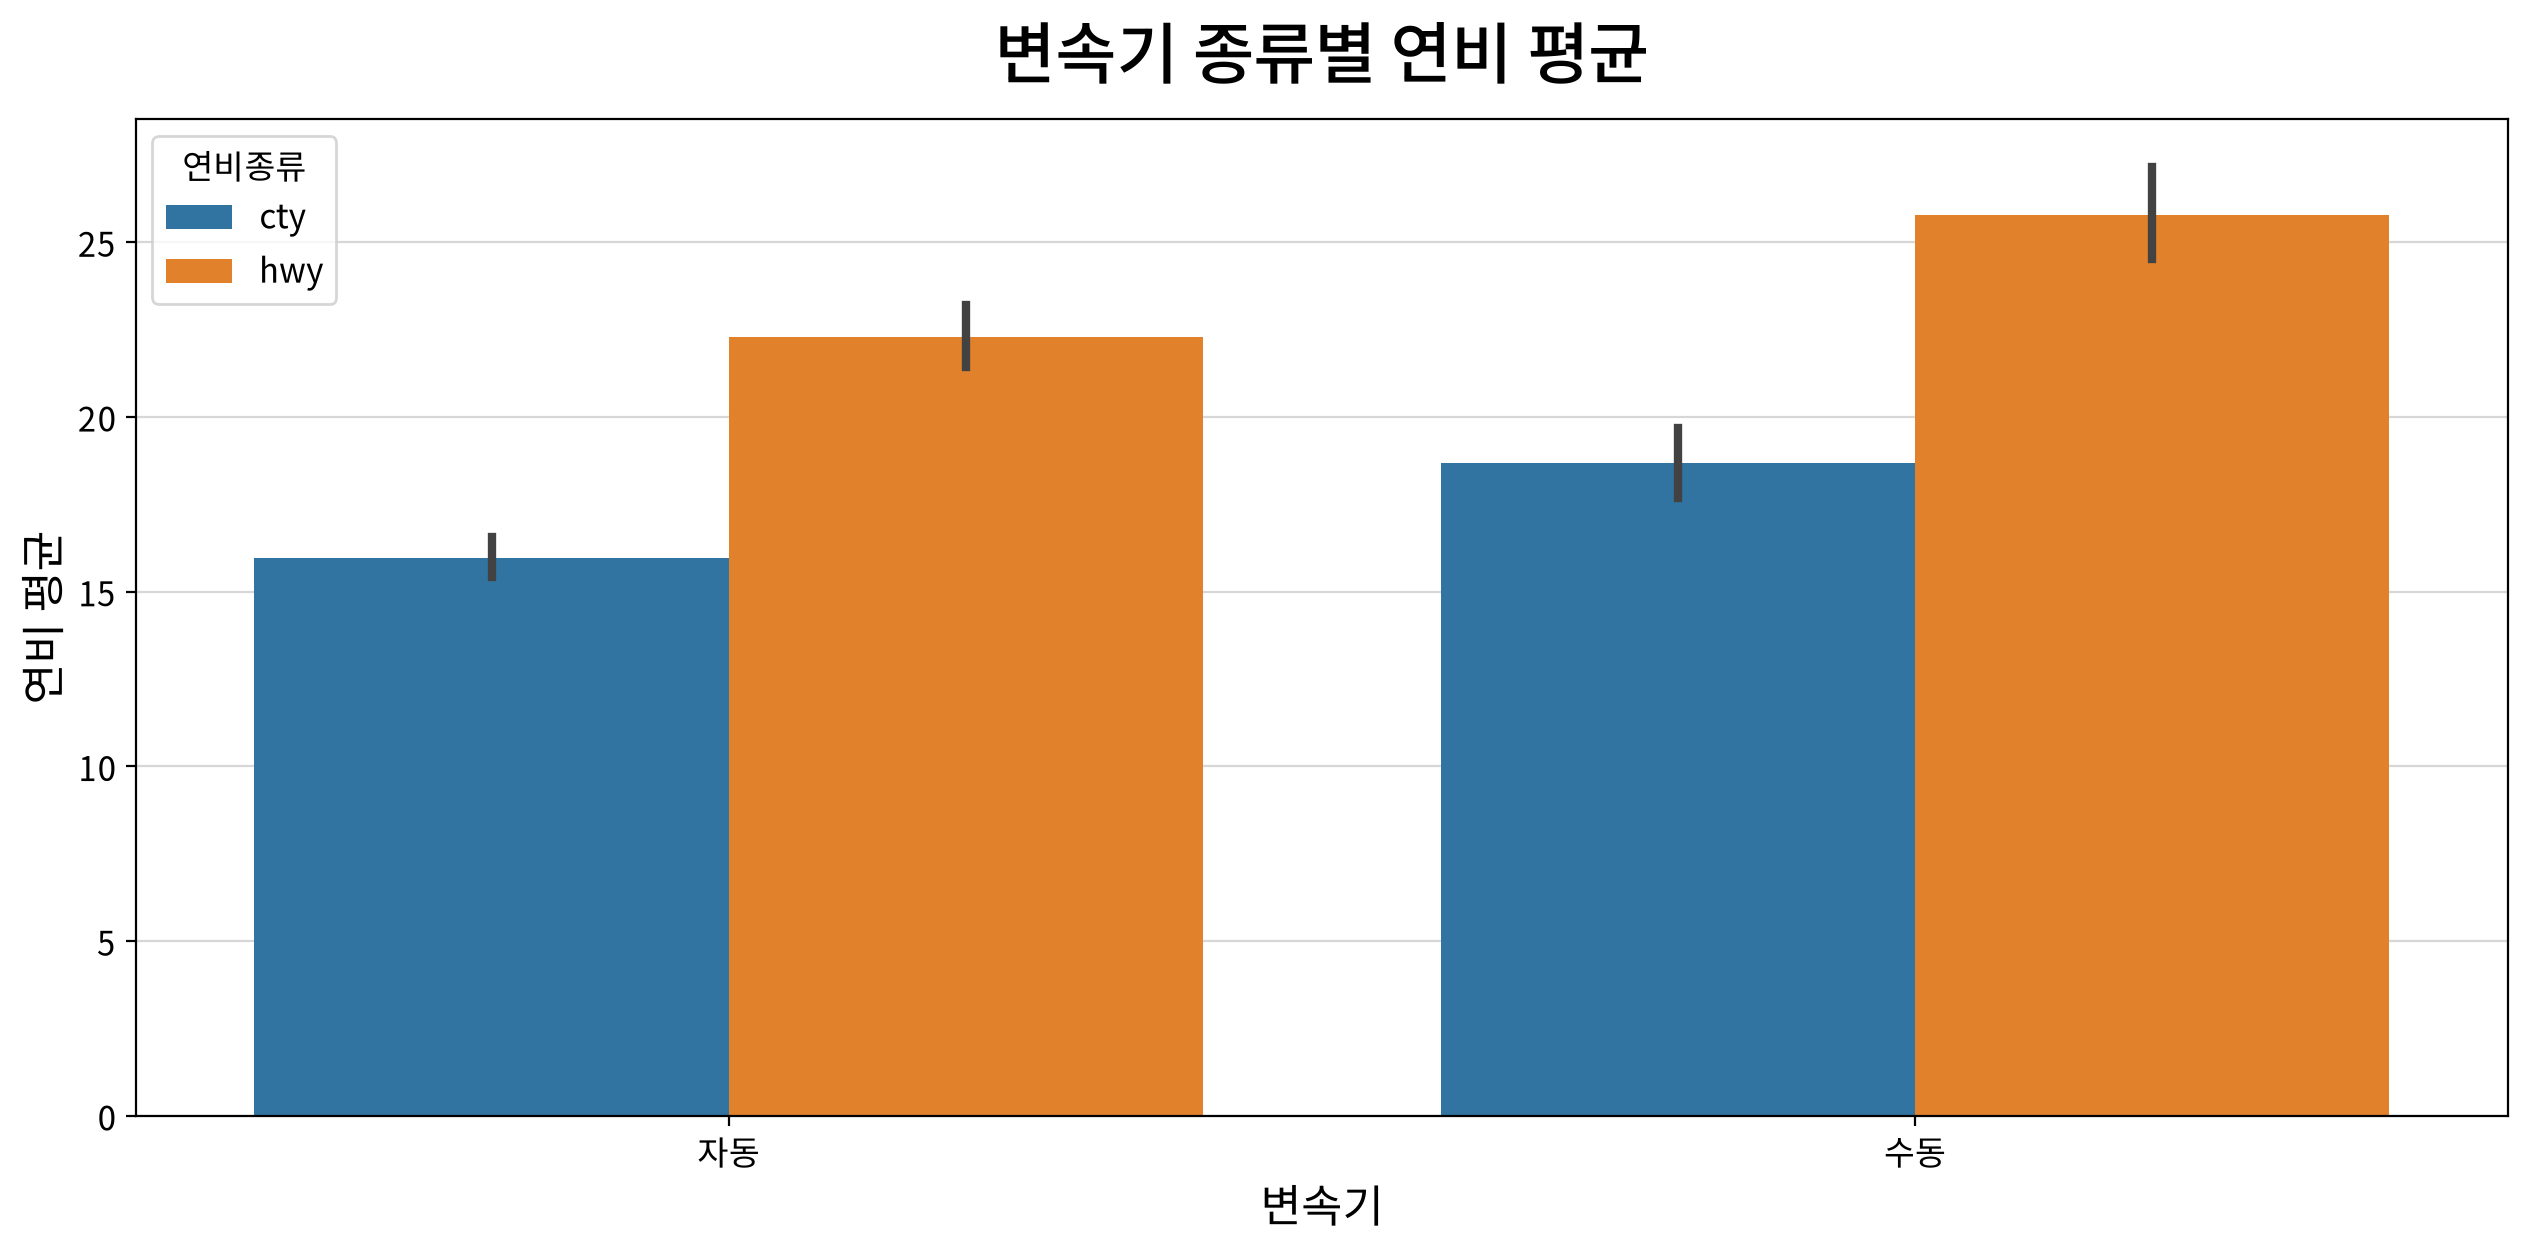

In [21]:
my_plot.barplot(data=df3, x="변속기", y="연비", hue="연비종류",
                title="변속기 종류별 연비 평균", 
                xlabel="변속기", ylabel="연비 평균")

## 문제 13. 가장 많이 사용된 연료(`fl`) 종류는?

① p (프리미엄)  ② r (레귤러)  ③ e (에탄올)  ④ d (디젤)

> 💡 **힌트**: 막대그래프 또는 원그래프 (연료별 빈도)

### 정답 및 해설

**정답: ② r (레귤러)**

연료별 빈도는 r 168대, p 52대, e 8대, d 5대, c 1대로 레귤러가 압도적으로 많습니다.


### 1. 막대 그래프로 집계하기

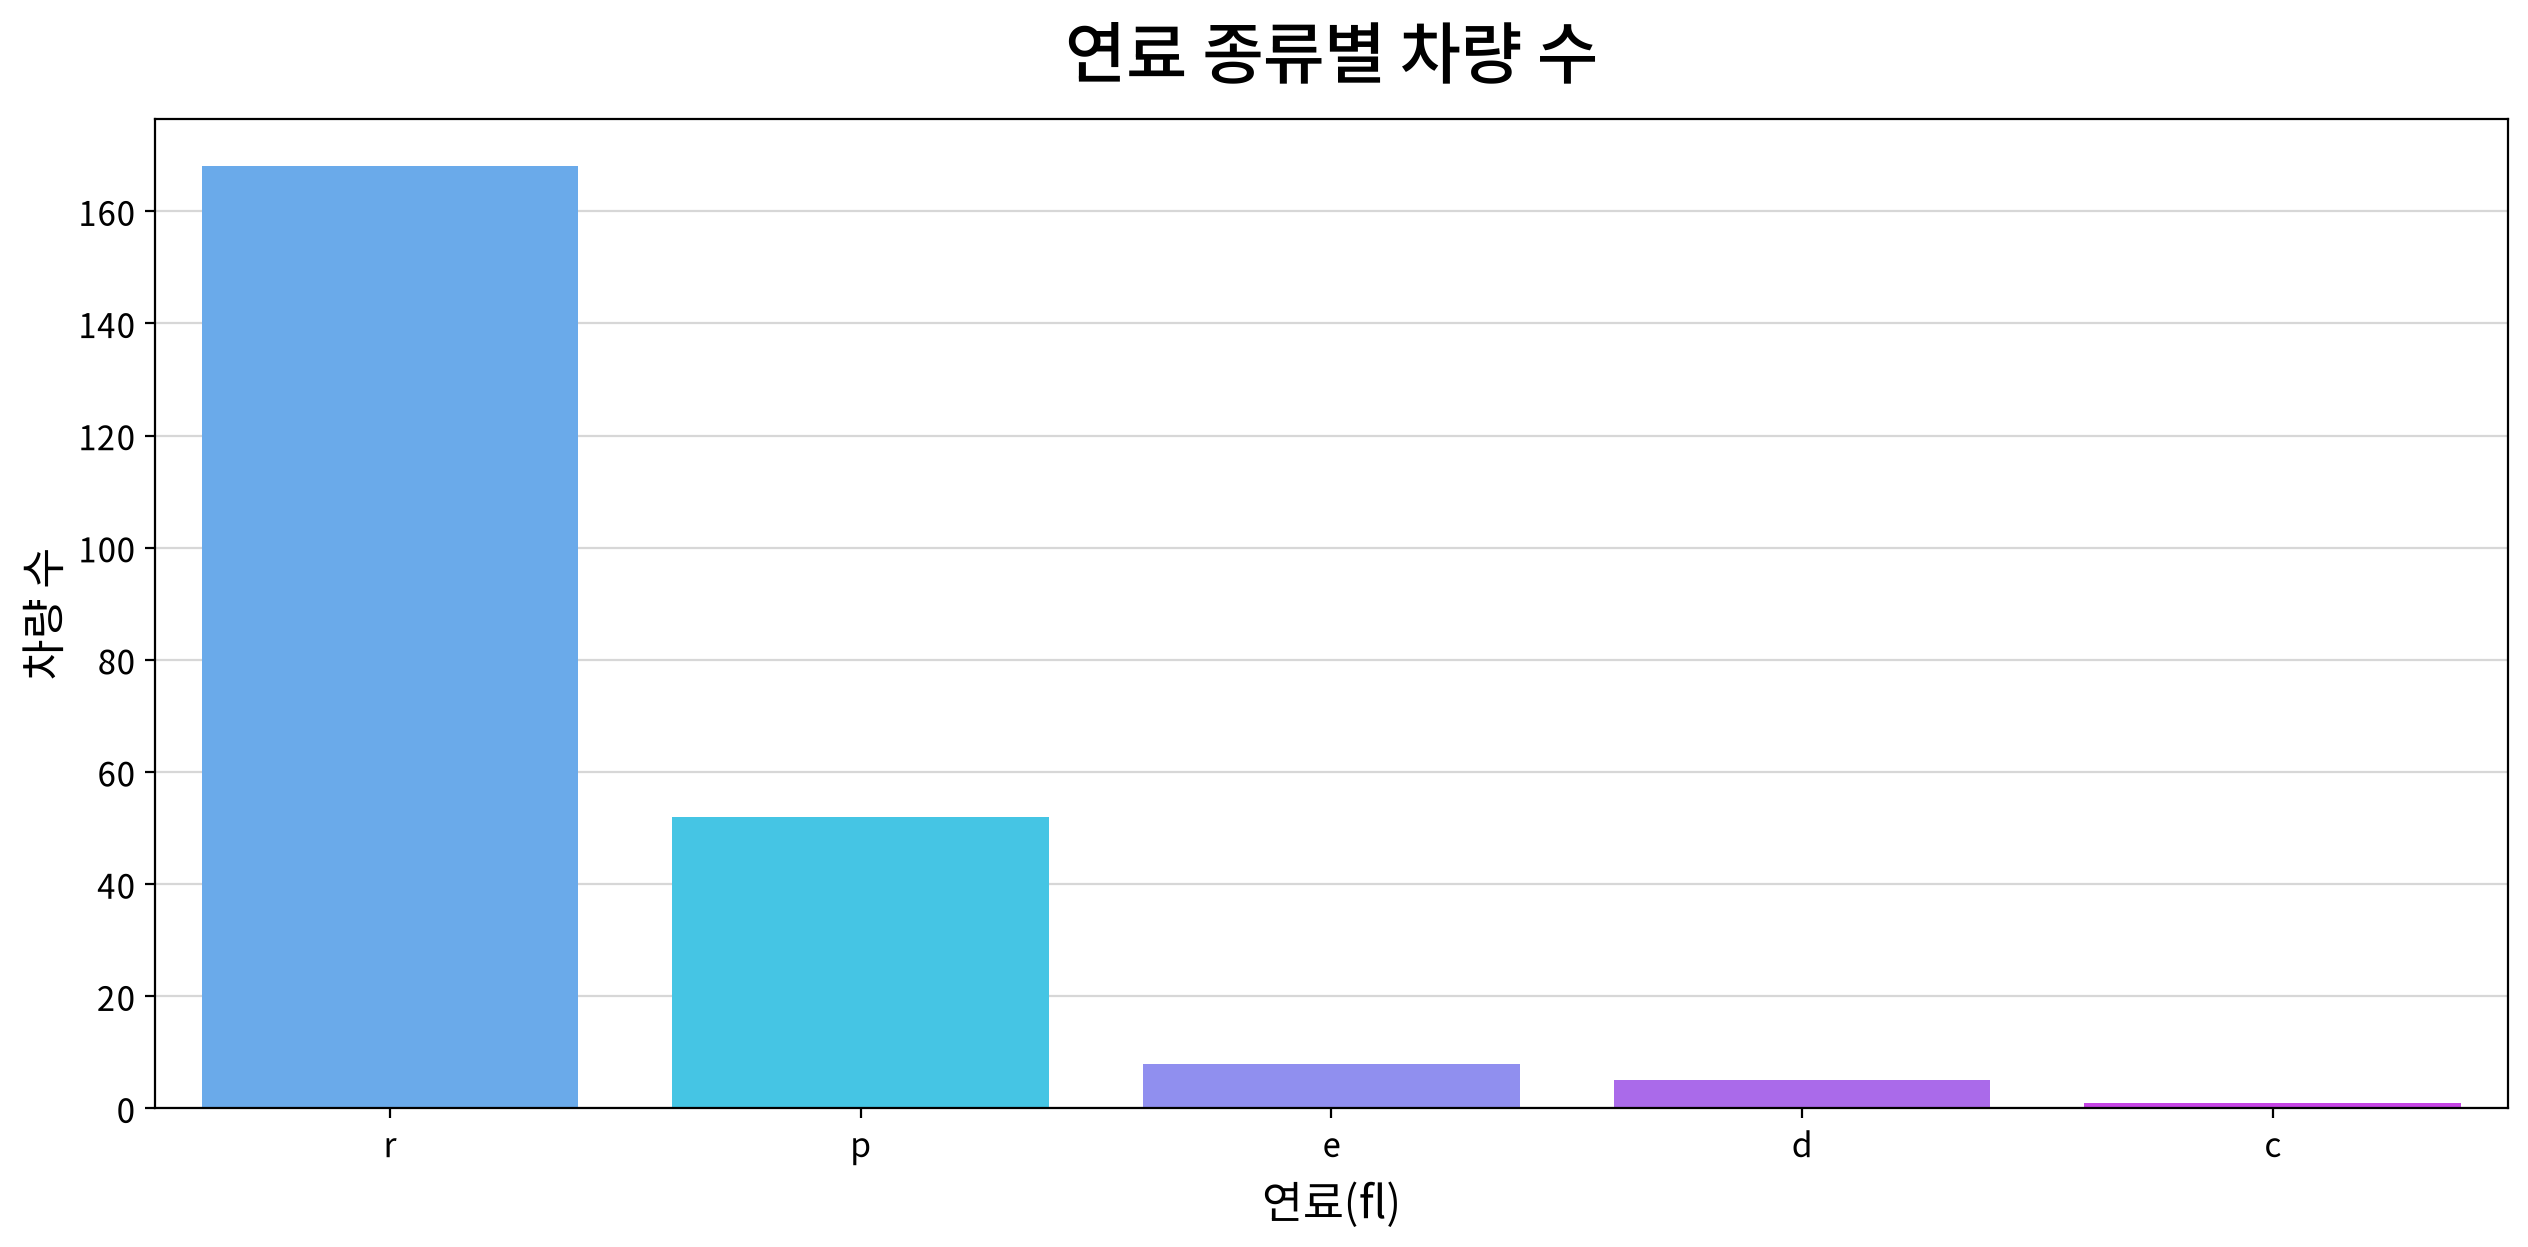

In [22]:
my_plot.countplot(data=df, x="fl", hue="fl", palette="cool", 
                order=df["fl"].value_counts().index,
                title="연료 종류별 차량 수", 
                xlabel="연료(fl)", ylabel="차량 수")

### 2. 파이 그래프로 집계하기

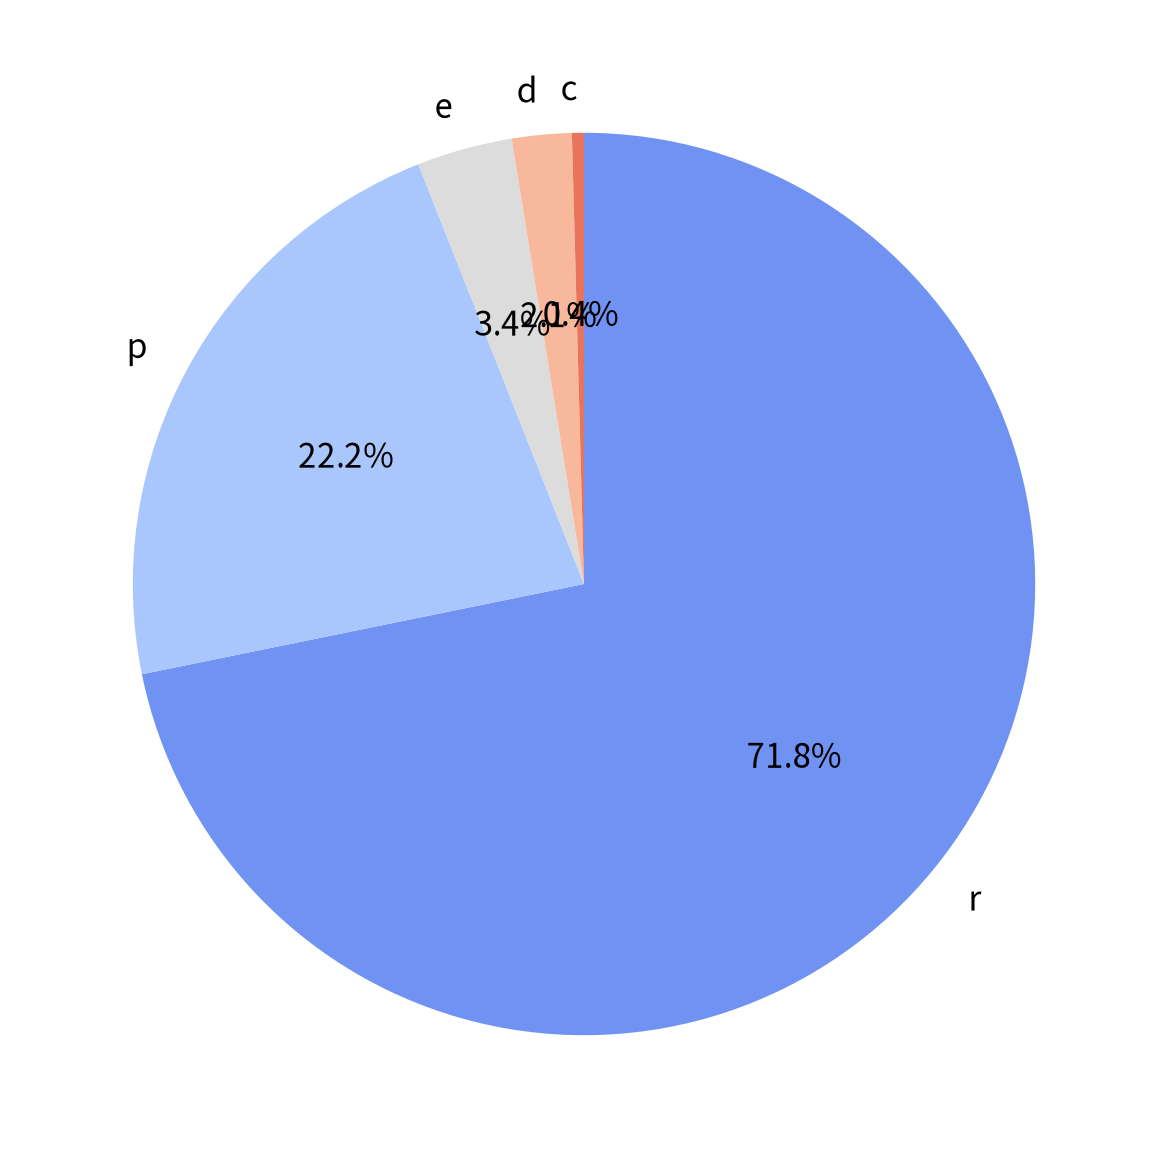

In [23]:
df2 = df["fl"].value_counts()
my_plot.pieplot(x=df2.values, labels=df2.index, palette="coolwarm", width=600, height=600)

## 문제 14. 1999년과 2008년의 평균 고속도로 연비(`hwy`)를 비교하면?

① 2008년이 크게 향상되었다  ② 1999년이 더 높다  ③ 거의 차이가 없다  ④ 2008년이 절반 수준이다

> 💡 **힌트**: 막대그래프 (연식별 hwy 평균)

### 정답 및 해설

**정답: ③ 거의 차이가 없다**

연식별 고속도로 연비 평균은 1999년 23.43, 2008년 23.45로 사실상 동일합니다. 9년의 시간차에도 평균 연비는 개선되지 않았음을 보여줍니다.


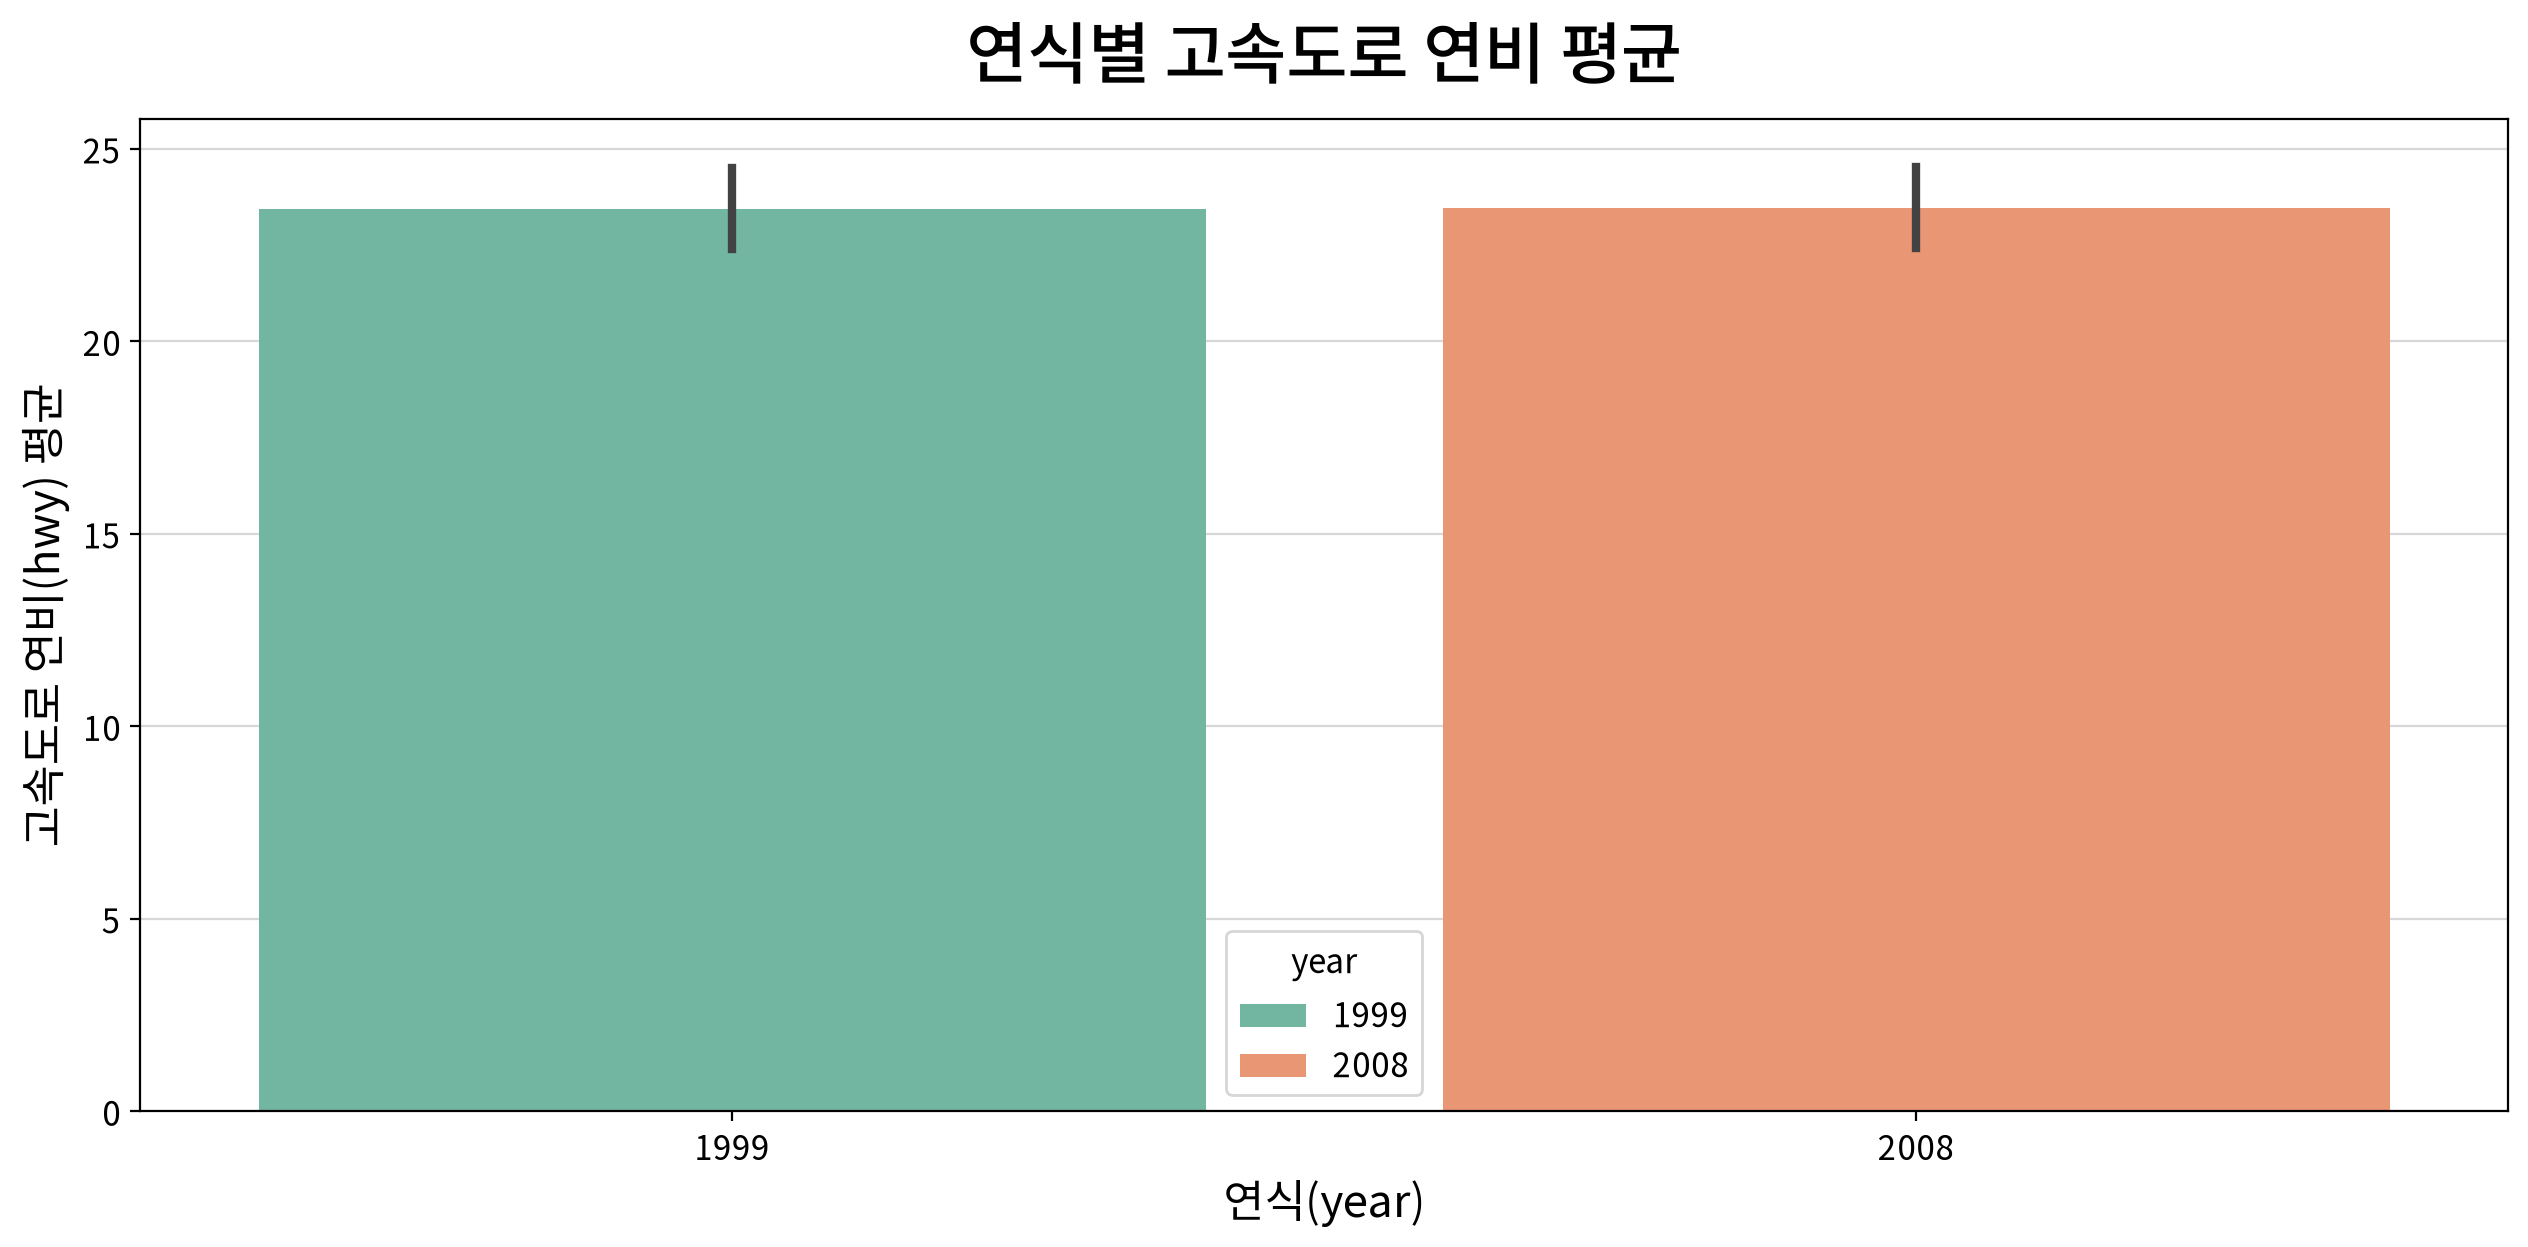

In [24]:
my_plot.barplot(data=df, x="year", y="hwy", 
                estimator="mean", hue="year", palette="Set2",
                title="연식별 고속도로 연비 평균", 
                xlabel="연식(year)", ylabel="고속도로 연비(hwy) 평균")

## 문제 15. SUV 차종에는 존재하지 않는 구동방식은?

① 4륜구동  ② 후륜구동  ③ 전륜구동  ④ 모두 존재한다

> 💡 **힌트**: 막대그래프 (차종 SUV로 필터 후 구동방식별 빈도) 또는 교차표 시각화

### 정답 및 해설

**정답: ③ 전륜구동**

SUV는 4륜구동 51대, 후륜구동 11대로만 구성되며 전륜구동 SUV는 한 대도 없습니다.


In [25]:
df2 = pivot_table(data=df, index="drv", columns='class', 
                  values='model', aggfunc='count', fill_value=0)
df2.sort_values(by="suv", ascending=False, inplace=True)
df2

class,2seater,compact,midsize,minivan,pickup,subcompact,suv
drv,,,,,,,
4륜구동,0,12,3,0,33,4,51
후륜구동,5,0,0,0,0,9,11
전륜구동,0,35,38,11,0,22,0


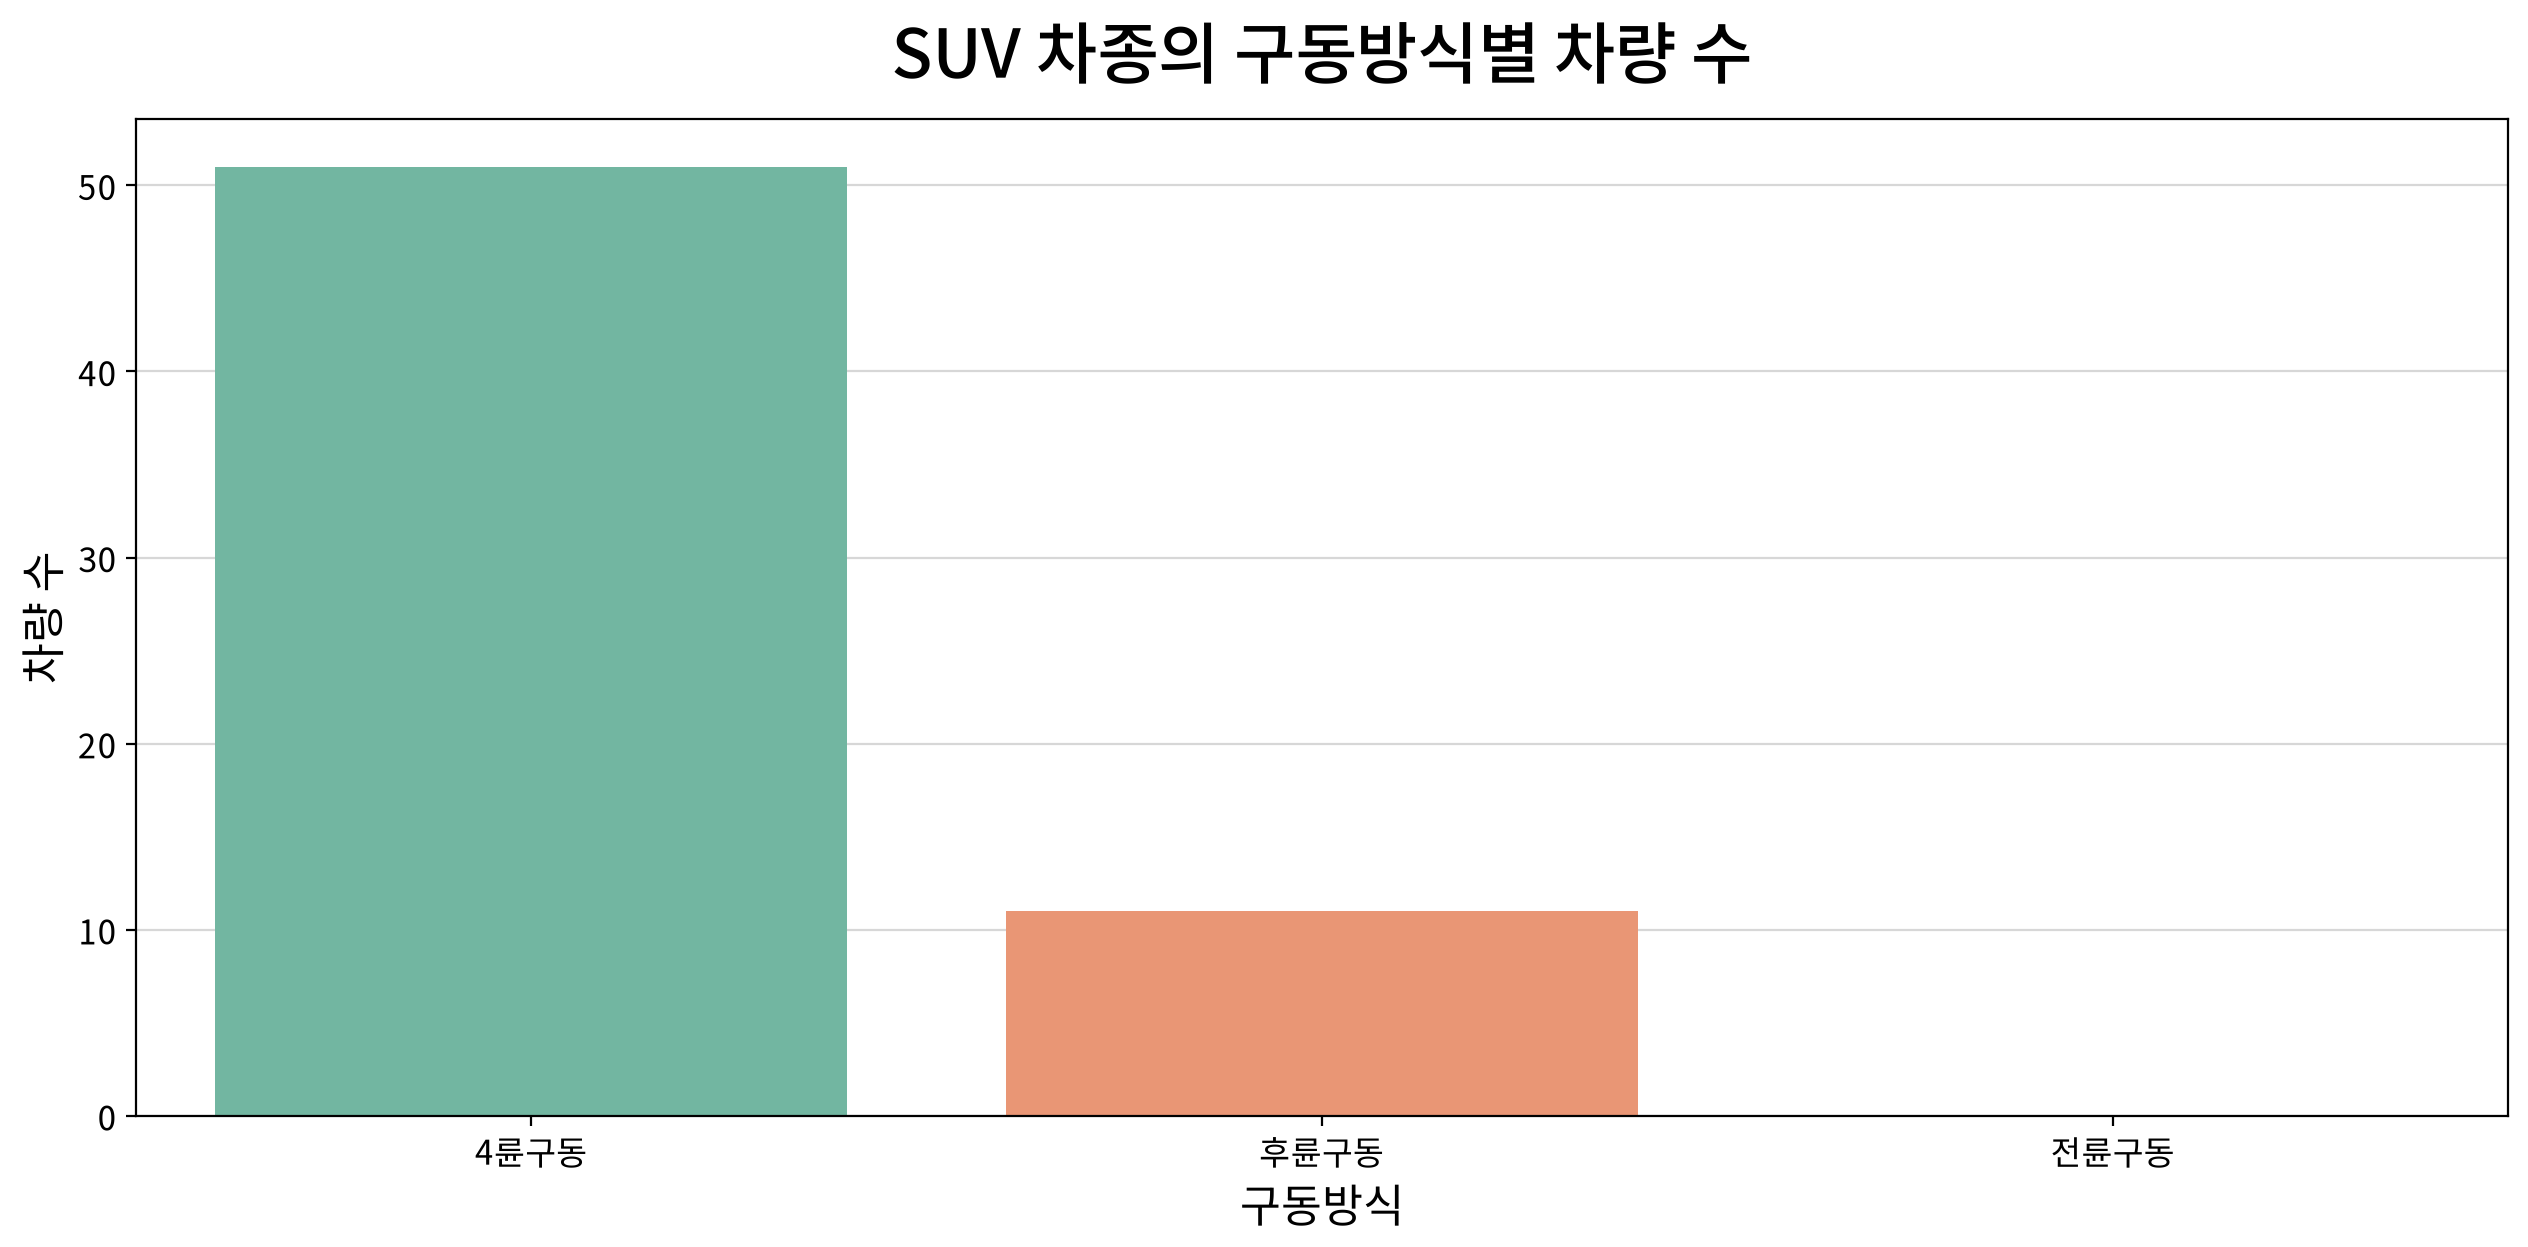

In [26]:
my_plot.barplot(data=df2, x=df2.index, y='suv', 
                hue=df2.index, palette="Set2",
                order=df2.index,
                title="SUV 차종의 구동방식별 차량 수", 
                xlabel="구동방식", ylabel="차량 수")

## 문제 16. 픽업(pickup) 차종의 구동방식은?

① 모두 4륜구동  ② 모두 전륜구동  ③ 4륜·후륜 혼합  ④ 전륜·4륜 혼합

> 💡 **힌트**: 막대그래프 (차종 pickup으로 필터 후 구동방식별 빈도)

### 정답 및 해설

**정답: ① 모두 4륜구동**

pickup 33대는 전부 4륜구동입니다. 막대그래프를 그리면 4륜구동 막대 하나만 나타납니다.


In [27]:
pickup = df[df["class"] == "pickup"]
pickup.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
49,dodge,dakota pickup 4wd,3.700,2008,6,manual(m6),4륜구동,15,19,r,pickup
50,dodge,dakota pickup 4wd,3.700,2008,6,auto(l4),4륜구동,14,18,r,pickup
51,dodge,dakota pickup 4wd,3.900,1999,6,auto(l4),4륜구동,13,17,r,pickup
52,dodge,dakota pickup 4wd,3.900,1999,6,manual(m5),4륜구동,14,17,r,pickup
53,dodge,dakota pickup 4wd,4.700,2008,8,auto(l5),4륜구동,14,19,r,pickup


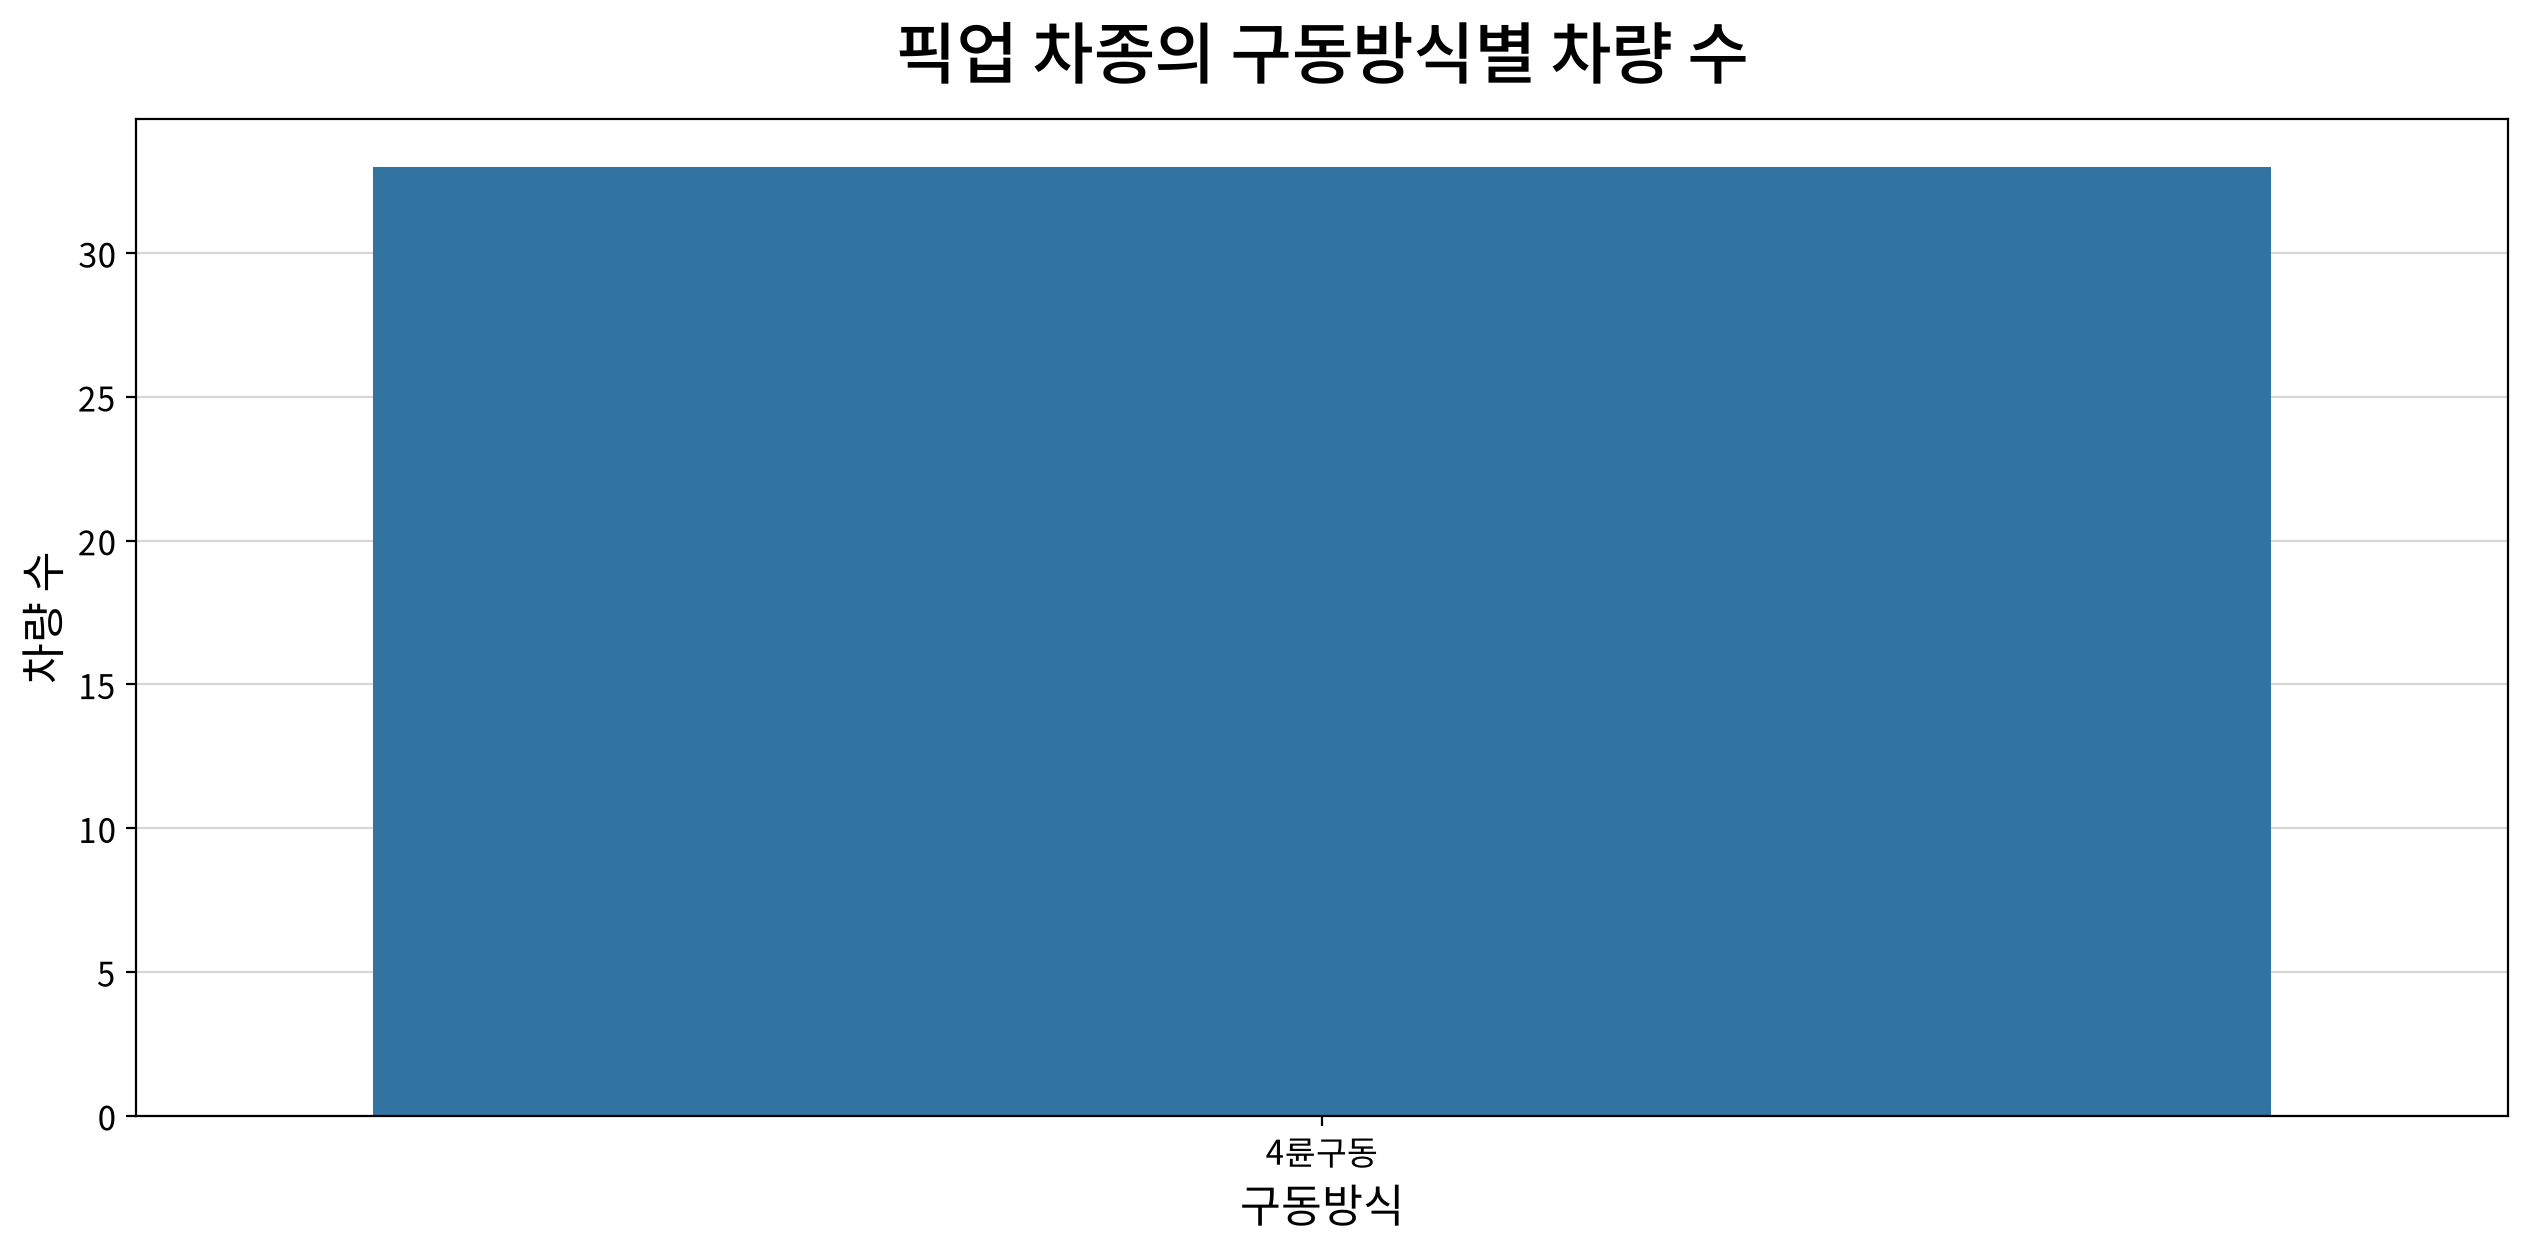

In [28]:
my_plot.countplot(data=pickup, x="drv",
                  title="픽업 차종의 구동방식별 차량 수", 
                  xlabel="구동방식", ylabel="차량 수")

## 문제 17. 평균연비 `(cty + hwy) / 2`가 전체 평균보다 높은(합격, Pass) 차량의 비율에 가장 가까운 값은?

① 약 25%  ② 약 47%  ③ 약 53%  ④ 약 75%

> 💡 **힌트**: 원그래프 (Pass/Fail 비율)

### 정답 및 해설

**정답: ③ 약 53%**

전체 평균연비는 약 20.15이며, 이를 초과하는 차량은 123대(Fail 111대)로 전체의 약 52.6%입니다.


In [29]:
df2 = df.copy()
df2['mean'] = (df2["cty"] + df2["hwy"]) / 2
df2.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,mean
id,,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact,23.500
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact,25.000
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact,25.500
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact,25.500
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact,21.000


In [30]:
threshold = df2["mean"].mean()                       # 전체 평균연비
df2["grade"] = np.where(df2["mean"] >= threshold, "Pass", "Fail")
df2.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,mean,grade
id,,,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact,23.500,Pass
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact,25.000,Pass
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact,25.500,Pass
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact,25.500,Pass
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact,21.000,Pass


In [31]:
vc = df2['grade'].value_counts()
vc

grade
Pass    123
Fail    111
Name: count, dtype: int64

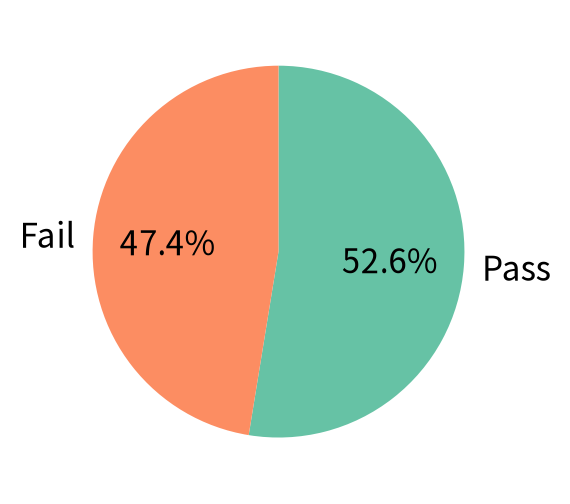

In [32]:
my_plot.pieplot(x=vc, labels=vc.index, palette="Set2", width=300, height=300)

## 문제 18. 배기량(`displ`) 분포의 중앙값(median)에 가장 가까운 값은?

① 2.4  ② 3.3  ③ 3.5  ④ 4.6

> 💡 **힌트**: 히스토그램 또는 박스플롯 (displ 분포)

### 정답 및 해설

**정답: ② 3.3**

`displ`의 사분위수는 최소 1.6, 1사분위 2.4, 중앙값 3.3, 3사분위 4.6, 최대 7.0입니다. 박스플롯의 중앙선 위치가 3.3입니다. (평균은 3.47로 중앙값보다 약간 큼 → 오른쪽 꼬리 분포)


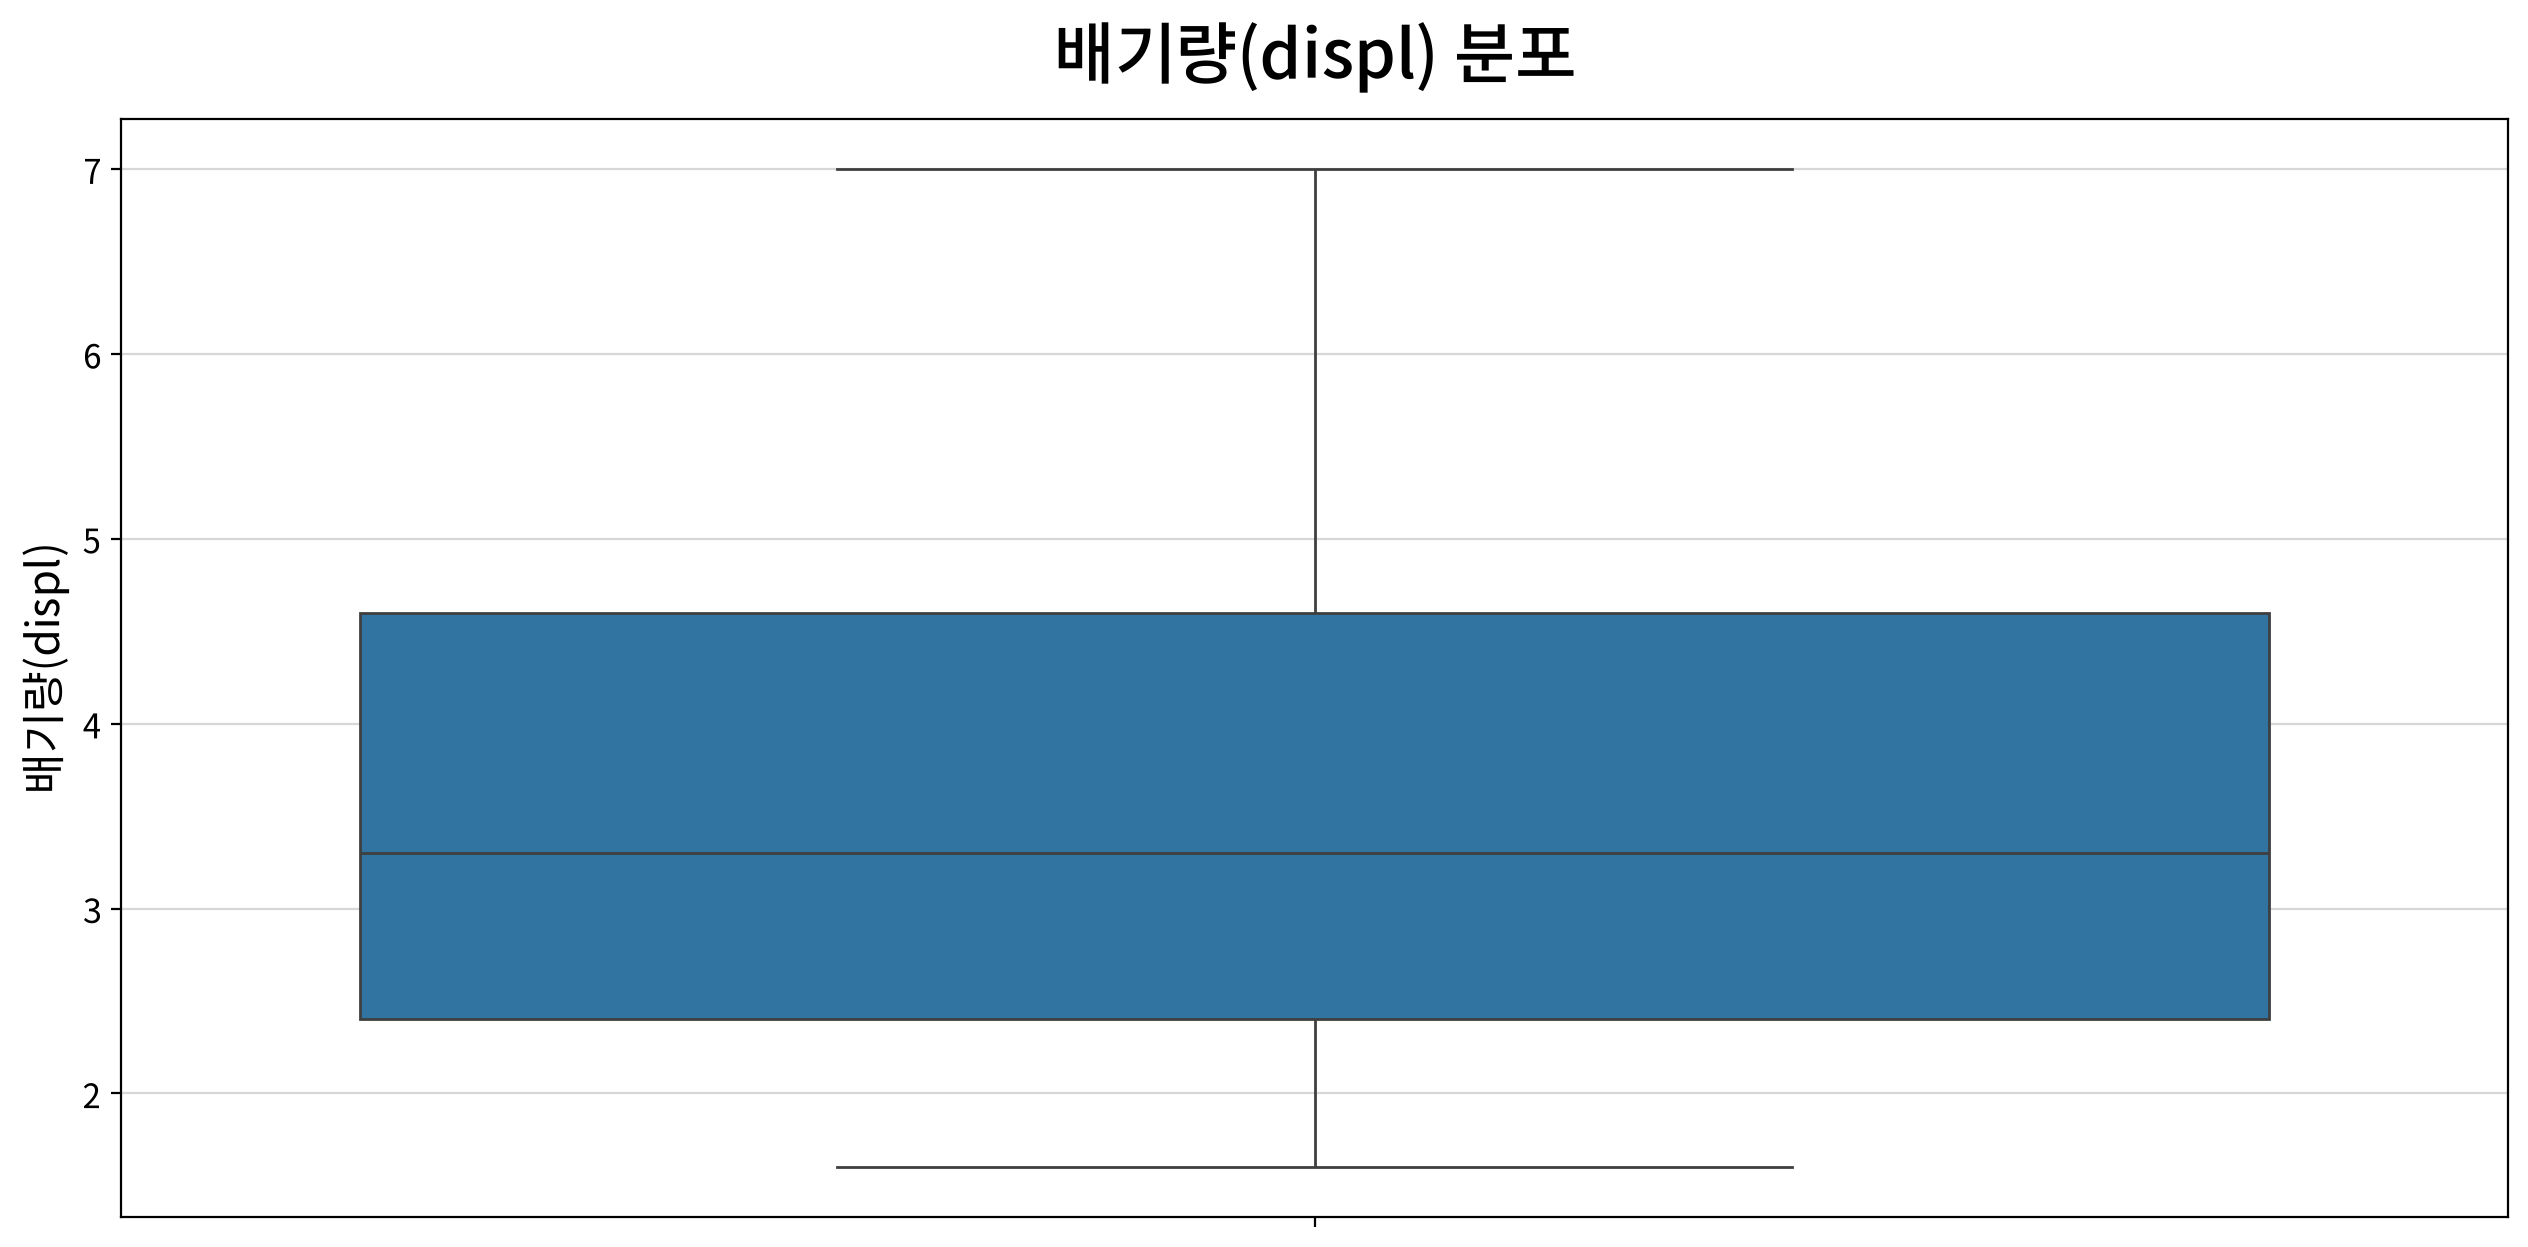

In [33]:
my_plot.boxplot(data=df, y="displ",
                title="배기량(displ) 분포", ylabel="배기량(displ)")